<a href="https://colab.research.google.com/github/narayananxyz/deep_learning/blob/main/capstone/Reference_Notebook_Facial_Emotion_Detection_Full_Code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Facial Emotion Detection**

## **Problem Definition**

**The context:** Why is this problem important to solve?<br>

Human emotions are central to communication, and a significant portion of human interaction is now happening through digital interfaces where emotional clues are lost. Automated facial emotion recognition has broad real-world applications — from understanding the customer mood, mental health monitoring, driver alertness detection, customer experience analysis in retail, and e-learning systems that can find how engaged students are. Building accurate, scalable emotion detection models can enable certain use cases to be better implement and build a more natural connection with humans.

**The objectives:** What is the intended goal?<br>

To build a deep learning model that can accurately classify facial expressions into one of four emotion categories happy, sad, neutral, and surprise using image data, with the goal of achieving the highest possible classification accuracy on unseen test data.

**The key questions:** What are the key questions that need to be answered?<br>

Can a CNN trained from scratch outperform pre-trained transfer learning models on grayscale emotion images?
Which emotions are hardest to distinguish and why?
Does color mode (grayscale vs RGB) meaningfully impact performance?
How many convolutional layers and parameters are needed for reliable emotion classification?
Does the data we have enough to build a good model.

**The problem formulation:** What are we trying to solve using data science?

This is a image classifiction problem. We are trying to classify 4 classes from a 48x48 grayscale facial image. using CNN as the primary approach we are going to tain and see if it can recognize facial features and see if it can lead to good classification accuracy.


## **About the dataset**

The data set consists of 3 folders, i.e., 'test', 'train', and 'validation'.
Each of these folders has four subfolders:

**‘happy’**: Images of people who have happy facial expressions.<br>
**‘sad’**: Images of people with sad or upset facial expressions.<br>
**‘surprise’**: Images of people who have shocked or surprised facial expressions.<br>
**‘neutral’**: Images of people showing no prominent emotion in their facial expression at all.<br>


## **Mounting the Drive**

**NOTE:**  Please use Google Colab from your browser for this notebook. **Google.colab is NOT a library that can be downloaded locally on your device.**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## **Importing the Libraries**

In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import h5py
import random
import cv2
import os
import shutil
import zipfile
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

### **Let us load and unzip the data**

**Note:**
- You must download the dataset from the link provided on Olympus and upload the same on your Google drive before executing the code in the next cell.
- In case of any error, please make sure that the path of the file is correct as the path may be different for you.

## IO Performace

IO performace can affect model tuning. The best performace I got was when I extracted the images locally. Copying the zip file into the local VM and extract it there, gives the best performace. We will need other techniques if the dataset is even larger, in this case this data set seems to fit in the disk space goolge colab is offering.

In [3]:
# Step 1 — Copy zip from Drive to local
print("Copying zip file from Drive...")
shutil.copy(
    '/content/drive/MyDrive/mitcourse/capstone/Facial_emotion_images.zip',
    '/content/Facial_emotion_images.zip'
)
print("Copy done!")

# Step 2 — Extract locally
print("Extracting...")
with zipfile.ZipFile('/content/Facial_emotion_images.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/')
print("Extraction done!")

# Step 3 — Verify structure
print("\nFolder structure:")
for split in ['train', 'validation', 'test']:
    path = f'/content/Facial_emotion_images/{split}'
    if os.path.exists(path):
        print(f"  {split}: {os.listdir(path)}")

# Step 4 -- Use local path

base_path = '/content/Facial_emotion_images/'

Copying zip file from Drive...
Copy done!
Extracting...
Extraction done!

Folder structure:
  train: ['sad', 'neutral', 'surprise', 'happy']
  validation: ['sad', 'neutral', 'surprise', 'happy']
  test: ['sad', 'neutral', 'surprise', 'happy']


## **Data Description**

The dataset consists of grayscale facial images collected from various sources across the internet, organized into four emotion categories: Happy, Sad, Neutral, and Surprise. Each image is 48x48 pixels in grayscale format, making it a relatively low-resolution dataset that challenges the model to extract meaningful facial features from limited pixel information.

The data is pre-split into three sets:

Train: 15,109 images (3,976 happy, 3,982 sad, 3,978 neutral, 3,173 surprise)
Validation: 4,977 images (1,825 happy, 1,139 sad, 1,216 neutral, 797 surprise)
Test: 128 images (32 per class, perfectly balanced)

The surprise class is notably underrepresented compared to the other three classes in both train and validation sets. The dataset contains real human faces of varying ages, ethnicities, and lighting conditions, along with some noisy samples including cartoons, placeholder images, and non-face images that were identified and removed during data preprocessing.

## **Visualizing our Classes**

Let's look at our classes.

**Write down your observation for each class. What do you think can be a unique feature of each emotion, that separates it from the remaining classes?**

Let's write a functon as we don't have re-code this for every class.

In [4]:
def show_class_samples(base_path, cls, split='train', samples=16, cols=8):
    cls_path = os.path.join(base_path, split, cls)
    images = random.sample(os.listdir(cls_path), samples)
    rows = samples // cols

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3.5))
    for j, img_name in enumerate(images):
        img = mpimg.imread(os.path.join(cls_path, img_name))
        axes[j//cols][j%cols].imshow(img, cmap='gray')
        axes[j//cols][j%cols].axis('off')

    plt.suptitle(cls.capitalize(), fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

### **Happy**

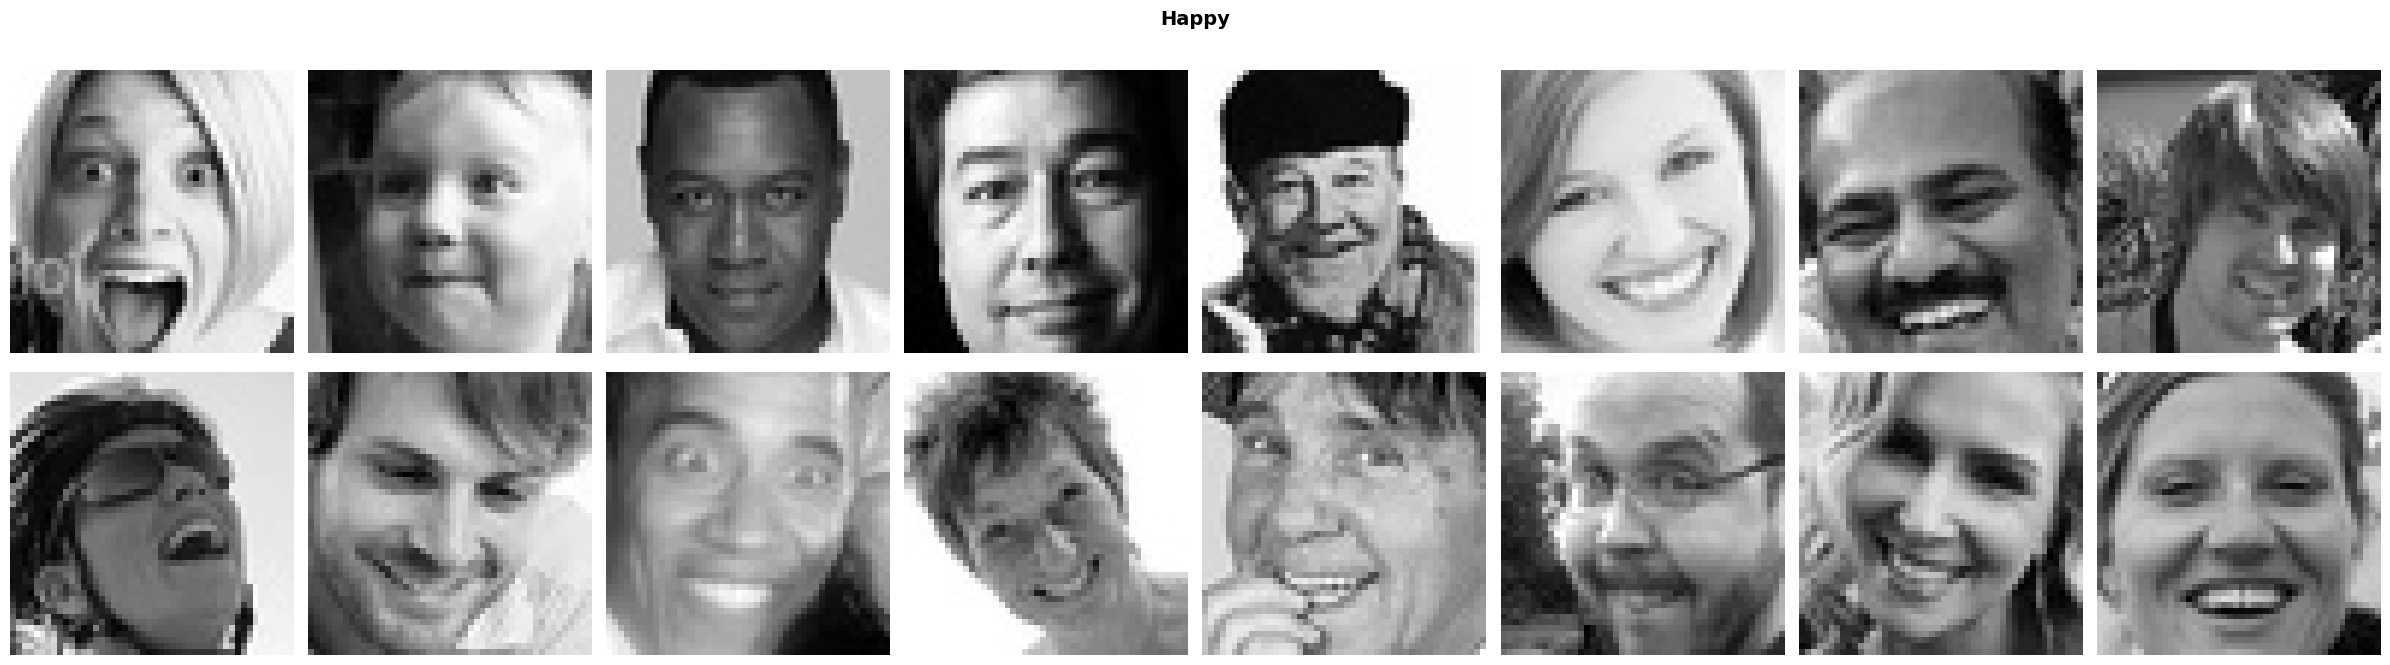

In [5]:
show_class_samples(base_path, 'happy')

**Observations and Insights:**
The most evident feature si the teeth surrounded by upward curved lips. cheek muscles move upward causing eyes to partially close in most cases. This migh be most visually distinct class due to the open mouth with teeth in most images.

### **Sad**

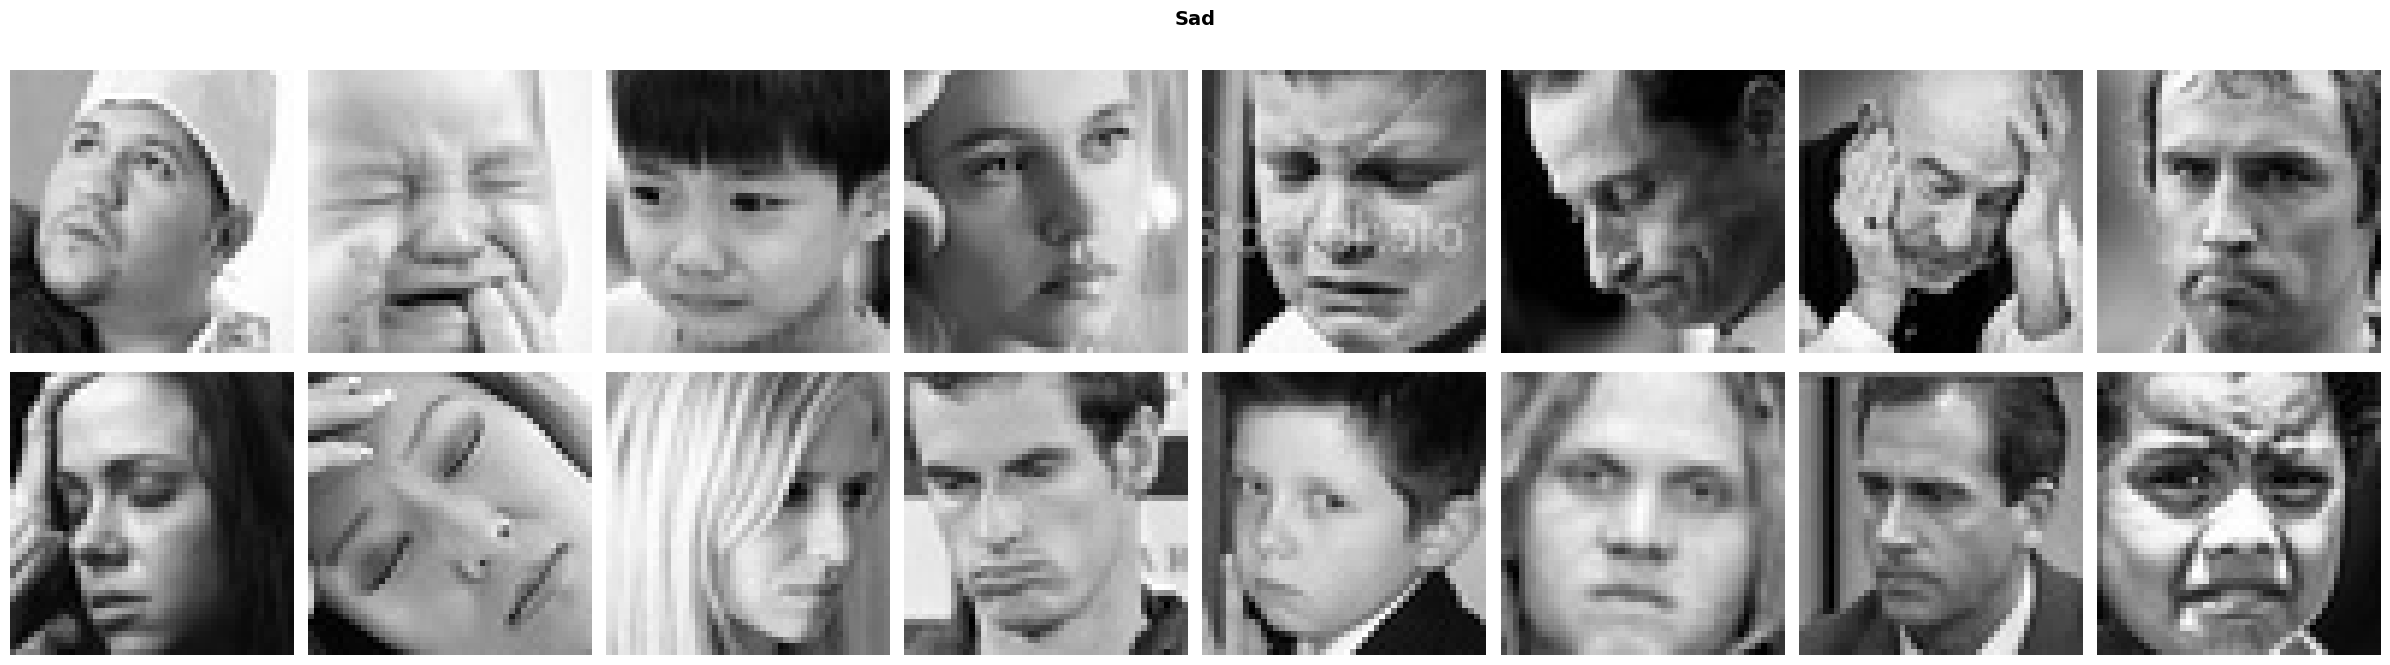

In [6]:
show_class_samples(base_path, 'sad')

**Observations and Insights:**
The face appears more shrunk and drooping eyes—opposite geometry to happy. While cheeks may appear raised in some cases like happy, the key differentiator is the absence of visible teeth. When present, tears are an easy feature. Head tilt downward is also seems in a lot of faces

### **Neutral**

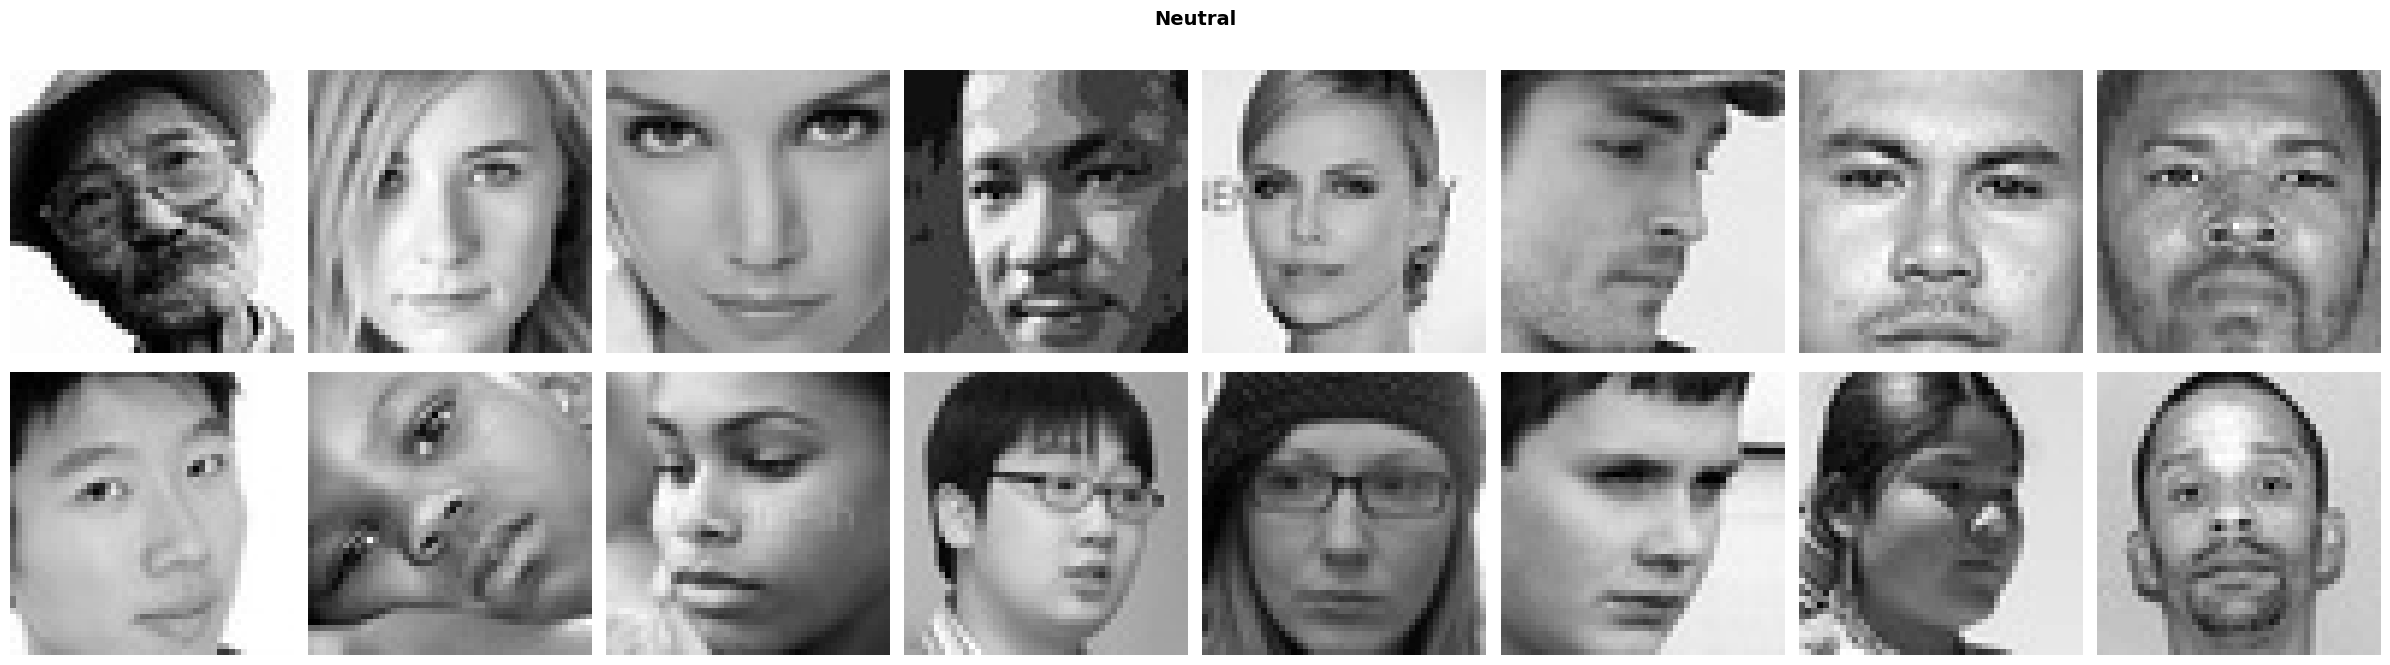

In [7]:
show_class_samples(base_path, 'neutral')

**Observations and Insights:**
This is more closer to sad but without the signs that the sad face gives (no tears, downward mouth etc..). Eyes are fully open and face is more relaxed and symmetric. this is going to hard to identify as it does not have anything significant to distinguish.

### **Surprised**

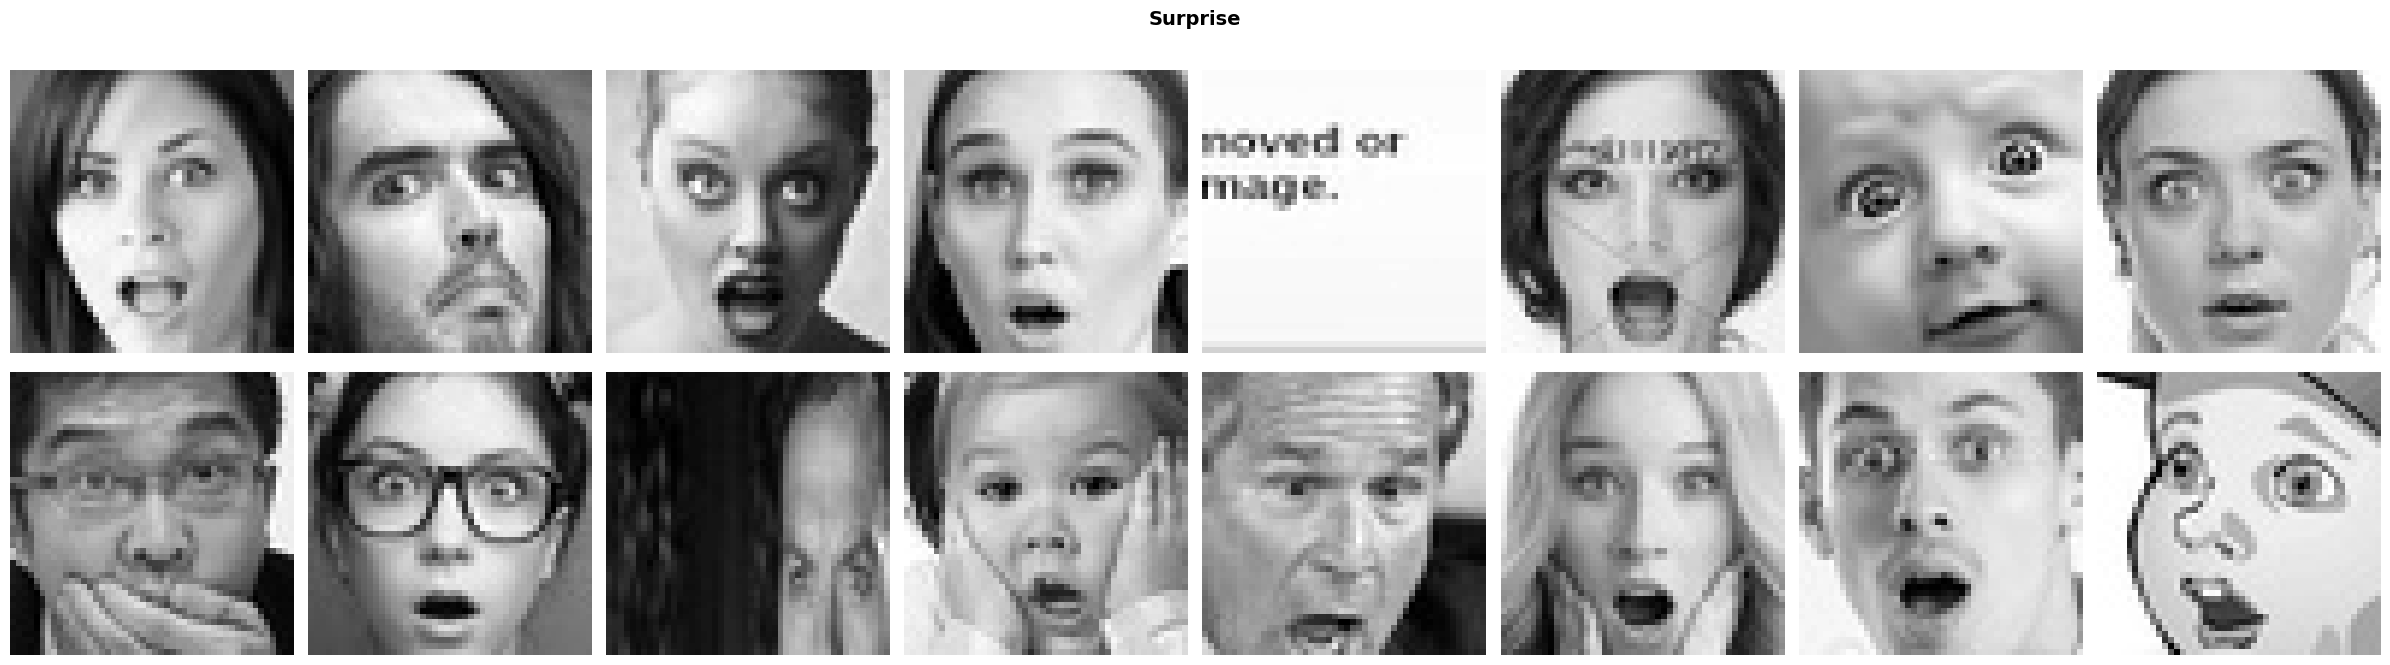

In [8]:
show_class_samples(base_path, 'surprise')

**Observations and Insights:**
Very dominant features in this class. Wide open O shaped mouth and wide open eyes. the vertical strech of the mouth along with a wide open eyes makes it very distinct from happy. This class should be easier to classify than the other classes.

## **Checking Distribution of Classes**

=== Image Count Per Class ===

TRAIN:
  happy     : 3976 images
  sad       : 3982 images
  surprise  : 3173 images
  neutral   : 3978 images
  TOTAL     : 15109 images

VALIDATION:
  happy     : 1825 images
  sad       : 1139 images
  surprise  : 797 images
  neutral   : 1216 images
  TOTAL     : 4977 images

TEST:
  happy     : 32 images
  sad       : 32 images
  surprise  : 32 images
  neutral   : 32 images
  TOTAL     : 128 images



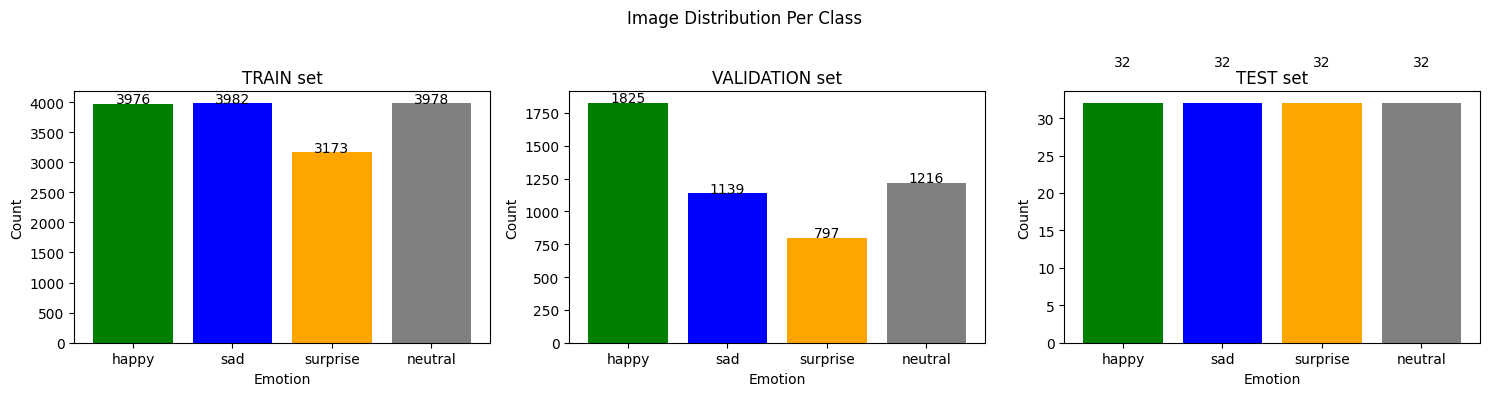

In [9]:

splits = ['train', 'validation', 'test']
emotions = ['happy', 'sad', 'surprise', 'neutral']

print("=== Image Count Per Class ===\n")

counts = {}
for split in splits:
    counts[split] = {}
    print(f"{split.upper()}:")
    total = 0
    for emotion in emotions:
        path = os.path.join(base_path, split, emotion)
        if os.path.exists(path):
            count = len(os.listdir(path))
            counts[split][emotion] = count
            total += count
            print(f"  {emotion:10s}: {count} images")
    print(f"  {'TOTAL':10s}: {total} images\n")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, split in enumerate(splits):
    values = [counts[split].get(e, 0) for e in emotions]
    axes[idx].bar(emotions, values, color=['green', 'blue', 'orange', 'gray'])
    axes[idx].set_title(f'{split.upper()} set')
    axes[idx].set_xlabel('Emotion')
    axes[idx].set_ylabel('Count')
    for i, v in enumerate(values):
        axes[idx].text(i, v + 5, str(v), ha='center')

plt.suptitle('Image Distribution Per Class')
plt.tight_layout()
plt.show()

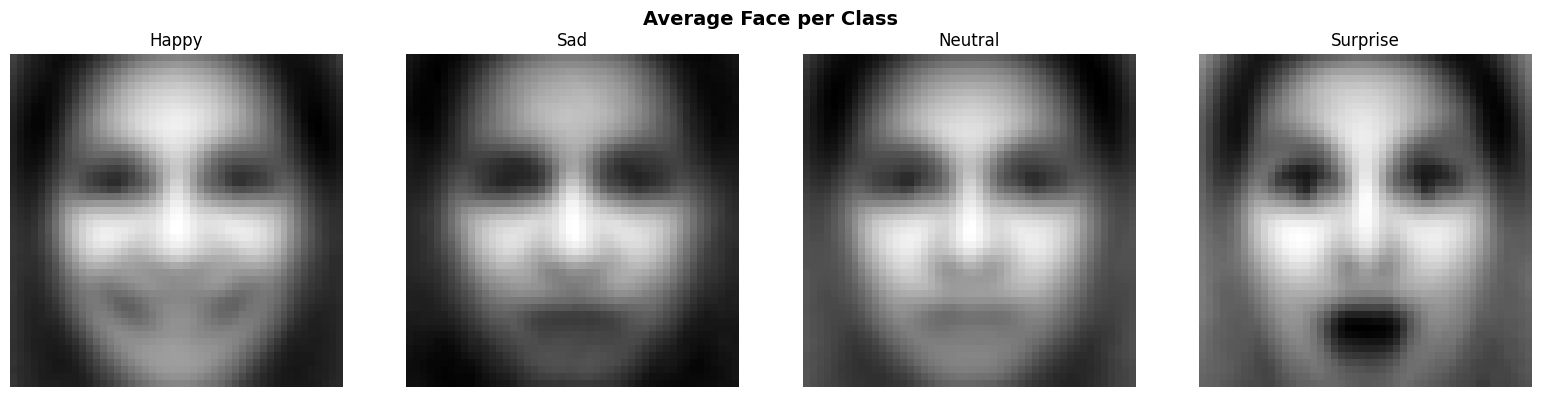

In [10]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for i, cls in enumerate(['happy', 'sad', 'neutral', 'surprise']):
    cls_path = os.path.join(base_path, 'train', cls)
    images = []
    for img_name in os.listdir(cls_path):
        img = mpimg.imread(os.path.join(cls_path, img_name))
        images.append(img)
    avg_face = np.mean(images, axis=0)
    axes[i].imshow(avg_face, cmap='gray')
    axes[i].set_title(cls.capitalize())
    axes[i].axis('off')

plt.suptitle('Average Face per Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Anamoly Detection and removal

We cna use the average and see the distance from the average and see if there any corrupted or bad images that we need to remove.



HAPPY — 5 anomalies found out of 3976


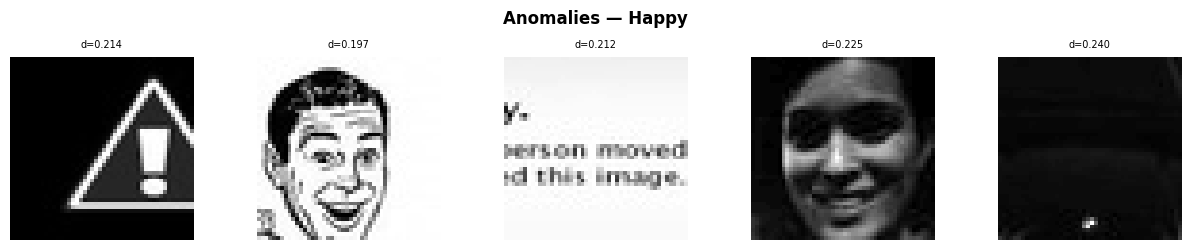


SAD — 3 anomalies found out of 3982


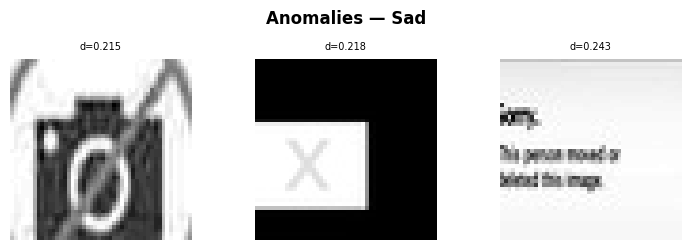


NEUTRAL — 8 anomalies found out of 3978


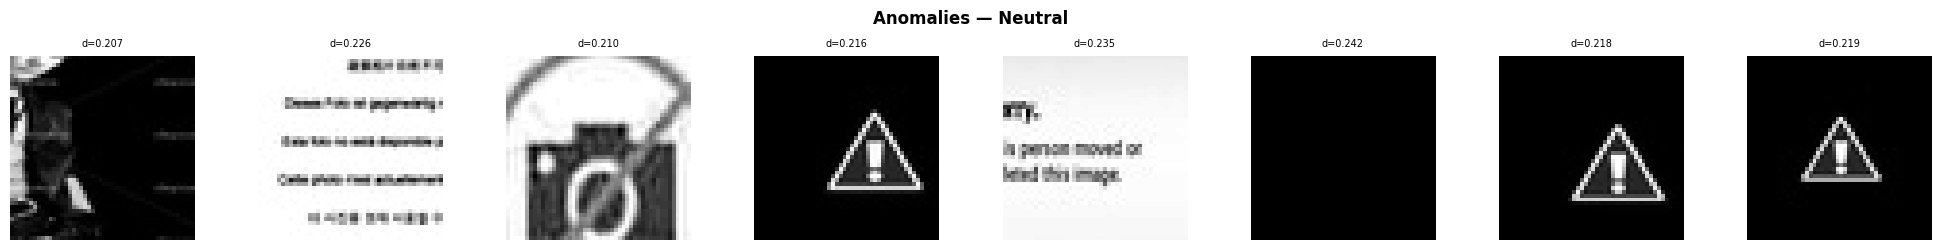


SURPRISE — 3 anomalies found out of 3173


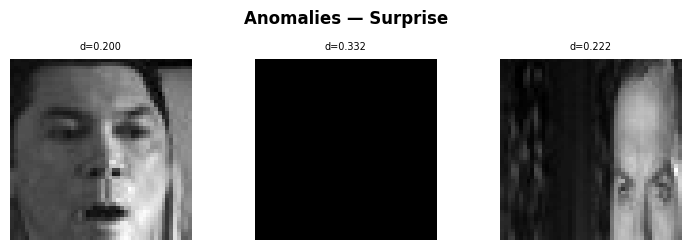

In [11]:
def find_anomalies(base_path, cls, split='train', threshold=2.0, show=True):
    cls_path = os.path.join(base_path, split, cls)
    img_names = os.listdir(cls_path)

    # Load all images
    images = []
    for img_name in img_names:
        img = mpimg.imread(os.path.join(cls_path, img_name))
        # Normalize to 0-1 if needed
        if img.max() > 1:
            img = img / 255.0
        images.append(img)

    images = np.array(images)
    avg_face = np.mean(images, axis=0)

    # Compute per-image distance from average
    distances = []
    for img in images:
        dist = np.mean((img - avg_face) ** 2)  # MSE from average
        distances.append(dist)

    distances = np.array(distances)
    mean_dist = np.mean(distances)
    std_dist = np.std(distances)

    # Flag images beyond threshold standard deviations
    anomaly_indices = np.where(distances > mean_dist + threshold * std_dist)[0]
    anomaly_names = [img_names[i] for i in anomaly_indices]

    print(f"\n{cls.upper()} — {len(anomaly_indices)} anomalies found out of {len(images)}")

    if show and len(anomaly_indices) > 0:
        cols = min(8, len(anomaly_indices))
        rows = (len(anomaly_indices) + cols - 1) // cols
        fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.5, rows * 2.5))
        axes = np.array(axes).flatten()
        for j, idx in enumerate(anomaly_indices):
            axes[j].imshow(images[idx], cmap='gray')
            axes[j].set_title(f'd={distances[idx]:.3f}', fontsize=7)
            axes[j].axis('off')
        # Hide unused axes
        for j in range(len(anomaly_indices), len(axes)):
            axes[j].axis('off')
        plt.suptitle(f'Anomalies — {cls.capitalize()}', fontsize=12, fontweight='bold')
        plt.tight_layout()
        plt.show()

    return anomaly_names

# Run for all classes
all_anomalies = {}
for cls in ['happy', 'sad', 'neutral', 'surprise']:
    all_anomalies[cls] = find_anomalies(base_path, cls, threshold=5.0)

We can see that there are some corrupted or incomplete images that we can remove.

In [12]:
# Print all anomalies found
print("Anomalies found:")
for cls, filenames in all_anomalies.items():
    print(f"\n{cls.upper()} ({len(filenames)}):")
    for fname in filenames:
        print(f"  {fname}")

# Delete them
def remove_anomalies(base_path, anomaly_dict):
    removed = 0
    for cls, filenames in anomaly_dict.items():
        for fname in filenames:
            fpath = os.path.join(base_path, 'train', cls, fname)
            if os.path.exists(fpath):
                os.remove(fpath)
                print(f"Removed: {cls}/{fname}")
                removed += 1
    print(f"\nTotal removed: {removed}")

remove_anomalies(base_path, all_anomalies)

Anomalies found:

HAPPY (5):
  26383.jpg
  18071.jpg
  24891.jpg
  20417.jpg
  29447.jpg

SAD (3):
  30705.jpg
  23894.jpg
  35632.jpg

NEUTRAL (8):
  31825.jpg
  19632.jpg
  17081.jpg
  25909.jpg
  15144.jpg
  22927.jpg
  34334.jpg
  25219.jpg

SURPRISE (3):
  27735.jpg
  13988.jpg
  32299.jpg
Removed: happy/26383.jpg
Removed: happy/18071.jpg
Removed: happy/24891.jpg
Removed: happy/20417.jpg
Removed: happy/29447.jpg
Removed: sad/30705.jpg
Removed: sad/23894.jpg
Removed: sad/35632.jpg
Removed: neutral/31825.jpg
Removed: neutral/19632.jpg
Removed: neutral/17081.jpg
Removed: neutral/25909.jpg
Removed: neutral/15144.jpg
Removed: neutral/22927.jpg
Removed: neutral/34334.jpg
Removed: neutral/25219.jpg
Removed: surprise/27735.jpg
Removed: surprise/13988.jpg
Removed: surprise/32299.jpg

Total removed: 19


**Observations and Insights:**

Distribution:
*   Training data is reasonably balanced with suprise being the outlier with fewer samples.
*   Validation data follows the same pattern, surprise is notably lower.
* Test set is perfectly balanced.
* Since the imbalance is not severe we can try to run and observe if there is any precision/recall issues and take call later, if we want to balance things better.

EDA Ideas:
* We can ensure that all the images are of equal size.
* We can get the pixel average of the all the images are geet a good idea on the features. i have the plotted them above.
* We can check all the images against the average and filter any bad or corrupted images.




**Think About It:**
* Are the classes equally distributed? If not, do you think the imbalance is too high? Will it be a problem as we progress?
* Are there any Exploratory Data Analysis tasks that we can do here? Would they provide any meaningful insights?

## **Creating our Data Loaders**

In this section, we are creating data loaders that we will use as inputs to our Neural Network.

**You have two options for the color_mode. You can set it to color_mode = 'rgb' or color_mode = 'grayscale'. You will need to try out both and see for yourself which one gives better performance.**

In [13]:
# Check image size
sample_path = os.path.join(base_path, 'train', 'happy')
sample_img = mpimg.imread(os.path.join(sample_path, os.listdir(sample_path)[0]))
print(sample_img.shape)

(48, 48)


In [ ]:
img_size = (48, 48)
batch_size = 32

# Try 'grayscale' or 'rgb'
color_mode = 'grayscale'  # change to 'rgb' to compare

datagen = ImageDataGenerator(rescale=1./255)

train_gen = datagen.flow_from_directory(
    os.path.join(base_path, 'train'),
    target_size=img_size,
    color_mode=color_mode,
    class_mode='categorical',
    batch_size=batch_size,
    shuffle=True
)

val_gen = datagen.flow_from_directory(
    os.path.join(base_path, 'validation'),
    target_size=img_size,
    color_mode=color_mode,
    class_mode='categorical',
    batch_size=batch_size,
    shuffle=False
)

test_gen = datagen.flow_from_directory(
    os.path.join(base_path, 'test'),
    target_size=img_size,
    color_mode=color_mode,
    class_mode='categorical',
    batch_size=batch_size,
    shuffle=False
)

print(f"Train: {train_gen.samples} | Val: {val_gen.samples} | Test: {test_gen.samples}")
print(f"Class indices: {train_gen.class_indices}")


color_mode = 'rgb'

train_gen_rgb = datagen.flow_from_directory(
    os.path.join(base_path, 'train'),
    target_size=img_size,
    color_mode=color_mode,
    class_mode='categorical',
    batch_size=batch_size,
    shuffle=True
)

val_gen_rgb = datagen.flow_from_directory(
    os.path.join(base_path, 'validation'),
    target_size=img_size,
    color_mode=color_mode,
    class_mode='categorical',
    batch_size=batch_size,
    shuffle=False
)

test_gen_rgb = datagen.flow_from_directory(
    os.path.join(base_path, 'test'),
    target_size=img_size,
    color_mode=color_mode,
    class_mode='categorical',
    batch_size=batch_size,
    shuffle=False
)

Found 15090 images belonging to 4 classes.
Found 4977 images belonging to 4 classes.
Found 128 images belonging to 4 classes.
Train: 15090 | Val: 4977 | Test: 128
Class indices: {'happy': 0, 'neutral': 1, 'sad': 2, 'surprise': 3}
Found 15090 images belonging to 4 classes.
Found 4977 images belonging to 4 classes.
Found 128 images belonging to 4 classes.


## **Data Pre-processing and Treatment**
The following pre-processing steps were applied before feeding images into the models:

* Pixel normalization — all pixel values rescaled from 0-255 to 0-1 range using rescale=1./255. This stabilizes gradient updates during training and speeds up convergence
* Image resizing — images confirmed at 48x48 pixels, consistent across all splits. Transfer learning models required upsampling to 224x224 to meet minimum input size requirements
* Color mode experimentation — models were trained with both grayscale (1 channel) and rgb (3 channels) to compare performance. RGB replicates the grayscale channel 3 times since images are already black and white
* Anomaly removal — images deviating more than 5 standard deviations from the class average pixel intensity were flagged and removed. This included cartoons, placeholder images, pure black images, and warning icons that would add noise to training
* Data splitting — dataset comes pre-split into train, validation, and test sets. No additional splitting was performed. Shuffle applied to training set only to ensure varied batches while keeping validation and test sets deterministic
* Batch size — set to 32 for all data loaders, balancing memory efficiency and gradient stability

## **Model Building**

**Think About It:**
* Are Convolutional Neural Networks the right approach? Should we have gone with Artificial Neural Networks instead?
* What are the advantages of CNNs over ANNs and are they applicable here?


ANNs would flatten the 48x48 image into 2304 inputs, destroying all spatial relationships between pixels, the relative positions of features is important for this detection, hence CNNs are better as we don't want to flatten

Advantages of ANN

*   CNNs learn spatial hierarchy. They learn local features first (edges, curves) then combine them to form higher features like eyes, mouth etch...
*   We need to detect the smile regardless of the position or title, CNNs will handle with via pooling
* Preserves local features like the curves for the lips when smiling, while ANN woulc have lost it.



### **Creating the Base Neural Network**

In [ ]:
tf.keras.backend.clear_session()
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

In [ ]:
# Build
def build_base_cnn(input_shape, num_classes=4):
    model = models.Sequential([
        # Block 1
        layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=input_shape),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),

        # Block 2
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),

        # Block 3
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),

        # Classifier
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

input_shape = (48, 48, 1)  # change to (48, 48, 3) if using rgb
model = build_base_cnn(input_shape)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,274,500 (4.86 MB)

 Trainable params: 1,274,052 (4.86 MB)

 Non-trainable params: 448 (1.75 KB)

### **Compiling and Training the Basic Model for grayscale**

In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
]

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=30,
    callbacks=callbacks
)


Epoch 1/30
472/472 ━━━━━━━━━━━━━━━━━━━━ 18s 27ms/step - accuracy: 0.4405 - loss: 1.3285 - val_accuracy: 0.5196 - val_loss: 1.1064 - learning_rate: 0.0010
Epoch 2/30
472/472 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.5648 - loss: 1.0057 - val_accuracy: 0.5935 - val_loss: 0.9737 - learning_rate: 0.0010
Epoch 3/30
472/472 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.6219 - loss: 0.8949 - val_accuracy: 0.6373 - val_loss: 0.9026 - learning_rate: 0.0010
Epoch 4/30
472/472 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.6531 - loss: 0.8313 - val_accuracy: 0.6781 - val_loss: 0.8064 - learning_rate: 0.0010
Epoch 5/30
472/472 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.6823 - loss: 0.7596 - val_accuracy: 0.6064 - val_loss: 0.9264 - learning_rate: 0.0010
Epoch 6/30
472/472 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.7032 - loss: 0.7083 - val_accuracy: 0.6721 - val_loss: 0.7957 - learning_rate: 0.0010
Epoch 7/30
472/472 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.7259 - loss: 0

In [20]:
def plot_history(history, title='Training History'):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Accuracy
    axes[0].plot(history.history['accuracy'], label='Train')
    axes[0].plot(history.history['val_accuracy'], label='Validation')
    axes[0].set_title('Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()

    # Loss
    axes[1].plot(history.history['loss'], label='Train')
    axes[1].plot(history.history['val_loss'], label='Validation')
    axes[1].set_title('Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()

    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

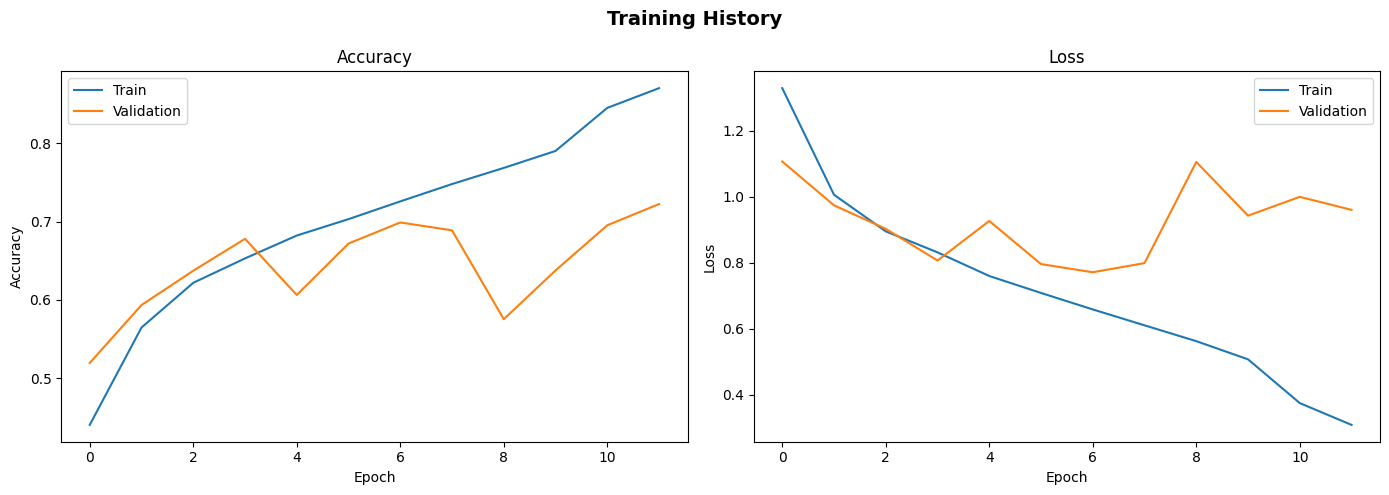

In [ ]:


plot_history(history)


### **Evaluating the Model on the Test Set for grayscale**

In [ ]:
# Evaluate
test_loss, test_acc = model.evaluate(test_gen)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7188 - loss: 0.6816
Test Loss: 0.6816
Test Accuracy: 0.7188


### **Compiling and Training the Basic Model for rgb**

In [ ]:
tf.keras.backend.clear_session()
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

input_shape = (48, 48, 3)
model_rgb = build_base_cnn(input_shape)
model_rgb.summary()

model_rgb.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
]

history_rgb = model_rgb.fit(
    train_gen_rgb,
    validation_data=val_gen_rgb,
    epochs=30,
    callbacks=callbacks
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,275,076 (4.86 MB)

 Trainable params: 1,274,628 (4.86 MB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/30
472/472 ━━━━━━━━━━━━━━━━━━━━ 19s 29ms/step - accuracy: 0.4410 - loss: 1.3219 - val_accuracy: 0.4718 - val_loss: 1.1836 - learning_rate: 0.0010
Epoch 2/30
472/472 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - accuracy: 0.5565 - loss: 1.0125 - val_accuracy: 0.5178 - val_loss: 1.0669 - learning_rate: 0.0010
Epoch 3/30
472/472 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.6093 - loss: 0.9143 - val_accuracy: 0.5817 - val_loss: 0.9844 - learning_rate: 0.0010
Epoch 4/30
472/472 ━━━━━━━━━━━━━━━━━━━━ 14s 29ms/step - accuracy: 0.6392 - loss: 0.8494 - val_accuracy: 0.6190 - val_loss: 0.9204 - learning_rate: 0.0010
Epoch 5/30
472/472 ━━━━━━━━━━━━━━━━━━━━ 15s 18ms/step - accuracy: 0.6696 - loss: 0.7941 - val_accuracy: 0.6307 - val_loss: 0.9174 - learning_rate: 0.0010
Epoch 6/30
472/472 ━━━━━━━━━━━━━━━━━━━━ 13s 27ms/step - accuracy: 0.6888 - loss: 0.7560 - val_accuracy: 0.6633 - val_loss: 0.8190 - learning_rate: 0.0010
Epoch 7/30
472/472 ━━━━━━━━━━━━━━━━━━━━ 18s 23ms/step - accuracy: 0.7171 - los

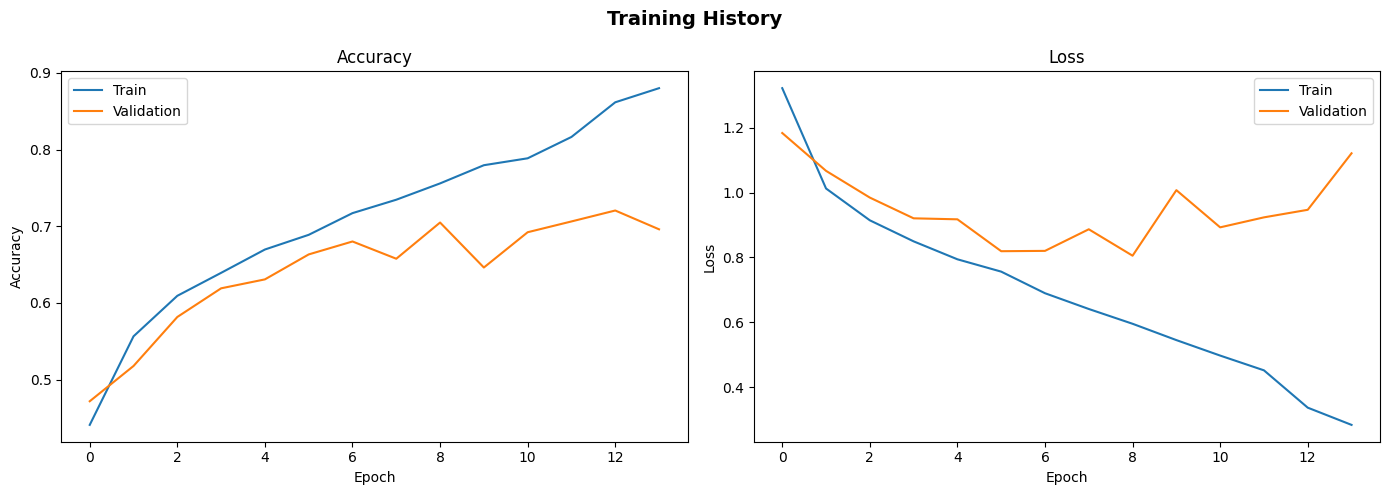

In [ ]:
plot_history(history_rgb)

### **Evaluating the Model on the Test Set for rgb**

In [ ]:
# Evaluate
test_loss_rgb, test_acc_rgb = model_rgb.evaluate(test_gen_rgb)
print(f"Test Loss: {test_loss_rgb:.4f}")
print(f"Test Accuracy: {test_acc_rgb:.4f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.7031 - loss: 0.6750
Test Loss: 0.6750
Test Accuracy: 0.7031


**Observations and Insights:**



*   Classic overfitting. Test accuracy is poor than validation accuracy.
*   RGB Vs Grayscale

RGB gives 3 channels (R, G, B) so the first conv layer has 3x more input signal to work with. Grayscale is 1 channel—pure intensity. For natural color photos RGB clearly wins because color carries real information. But for this dataset the images are already black and white, so RGB just copies the same grayscale channel 3 times.

Sometimes RGB might just perform better even on grayscale imges not because it is going to give any color. just that it has mode input to work with even if it is duplicate. for this one, it does not show any significant difference.



### **Creating the second Convolutional Neural Network**

- Try out a slightly larger architecture

In [ ]:
tf.keras.backend.clear_session()
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

In [ ]:
def build_cnn_v2(input_shape, num_classes=4):
    model = models.Sequential([
        # Block 1
        layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=input_shape),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),

        # Block 2
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),

        # Block 3
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),

        # Block 4
        layers.Conv2D(256, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),

        # Classifier
        layers.Flatten(),
        layers.Dense(512, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

input_shape = (48, 48, 1)
model_v2 = build_cnn_v2(input_shape)
model_v2.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 6, 6, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 6, 6, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 3, 3, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,898,980 (7.24 MB)

 Trainable params: 1,896,548 (7.23 MB)

 Non-trainable params: 2,432 (9.50 KB)

### **Compiling and Training the Model V2 grayscale**

In [ ]:
model_v2.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
]

history = model_v2.fit(
    train_gen,
    validation_data=val_gen,
    epochs=30,
    callbacks=callbacks
)


Epoch 1/30
472/472 ━━━━━━━━━━━━━━━━━━━━ 39s 47ms/step - accuracy: 0.3782 - loss: 1.6113 - val_accuracy: 0.3745 - val_loss: 1.8712 - learning_rate: 0.0010
Epoch 2/30
472/472 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.5292 - loss: 1.0640 - val_accuracy: 0.6170 - val_loss: 0.9332 - learning_rate: 0.0010
Epoch 3/30
472/472 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.6107 - loss: 0.9176 - val_accuracy: 0.6655 - val_loss: 0.8054 - learning_rate: 0.0010
Epoch 4/30
472/472 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.6506 - loss: 0.8351 - val_accuracy: 0.6492 - val_loss: 0.8402 - learning_rate: 0.0010
Epoch 5/30
472/472 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - accuracy: 0.6710 - loss: 0.7837 - val_accuracy: 0.6590 - val_loss: 0.8180 - learning_rate: 0.0010
Epoch 6/30
472/472 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - accuracy: 0.6920 - loss: 0.7431 - val_accuracy: 0.7171 - val_loss: 0.7007 - learning_rate: 0.0010
Epoch 7/30
472/472 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - accuracy: 0.7110 - loss

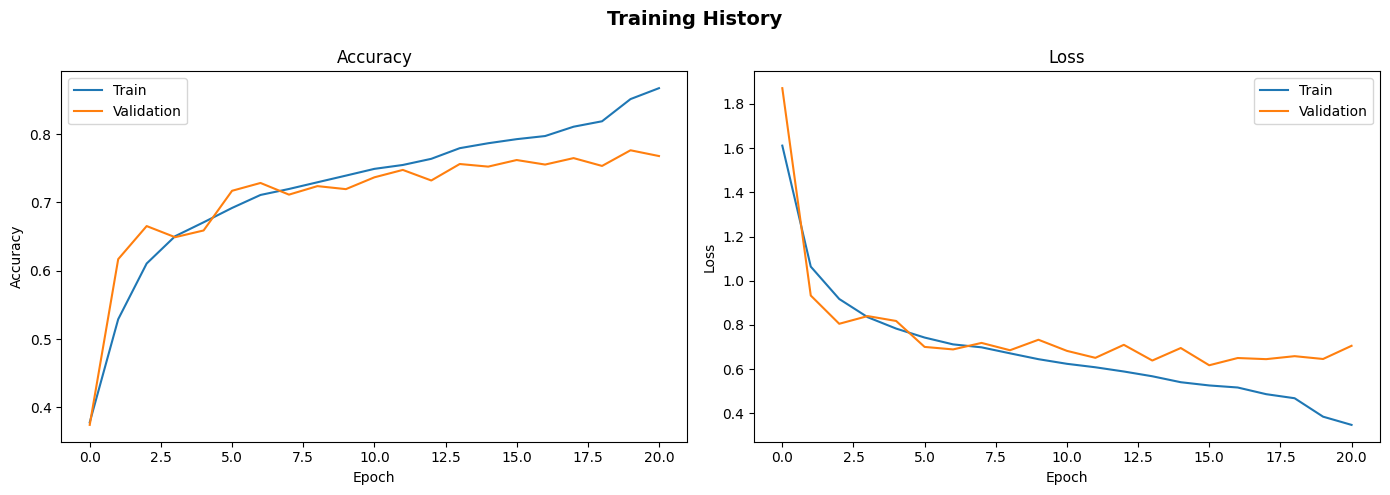

In [ ]:
plot_history(history)

### **Evaluating the Model v2 on the Test Set grayscale**

In [ ]:
# Evaluate
test_loss_v2, test_acc_v2 = model_v2.evaluate(test_gen)
print(f"Test Loss: {test_loss_v2:.4f}")
print(f"Test Accuracy: {test_acc_v2:.4f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7578 - loss: 0.5901
Test Loss: 0.5901
Test Accuracy: 0.7578


### **Compiling and Training the Model V2 rgb**

In [ ]:
tf.keras.backend.clear_session()
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

In [ ]:
input_shape = (48, 48, 3)
model_v2_rgb = build_cnn_v2(input_shape)
model_v2_rgb.summary()


model_v2_rgb.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
]

history = model_v2_rgb.fit(
    train_gen_rgb,
    validation_data=val_gen_rgb,
    epochs=30,
    callbacks=callbacks
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 6, 6, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 6, 6, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 3, 3, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,899,556 (7.25 MB)

 Trainable params: 1,897,124 (7.24 MB)

 Non-trainable params: 2,432 (9.50 KB)

Epoch 1/30
472/472 ━━━━━━━━━━━━━━━━━━━━ 43s 41ms/step - accuracy: 0.3639 - loss: 1.6465 - val_accuracy: 0.4352 - val_loss: 1.2130 - learning_rate: 0.0010
Epoch 2/30
472/472 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.5110 - loss: 1.1090 - val_accuracy: 0.5608 - val_loss: 1.0002 - learning_rate: 0.0010
Epoch 3/30
472/472 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.6018 - loss: 0.9358 - val_accuracy: 0.6428 - val_loss: 0.8503 - learning_rate: 0.0010
Epoch 4/30
472/472 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - accuracy: 0.6372 - loss: 0.8494 - val_accuracy: 0.6631 - val_loss: 0.8498 - learning_rate: 0.0010
Epoch 5/30
472/472 ━━━━━━━━━━━━━━━━━━━━ 15s 32ms/step - accuracy: 0.6641 - loss: 0.8028 - val_accuracy: 0.6498 - val_loss: 0.8583 - learning_rate: 0.0010
Epoch 6/30
472/472 ━━━━━━━━━━━━━━━━━━━━ 16s 23ms/step - accuracy: 0.6870 - loss: 0.7595 - val_accuracy: 0.7157 - val_loss: 0.6954 - learning_rate: 0.0010
Epoch 7/30
472/472 ━━━━━━━━━━━━━━━━━━━━ 19s 21ms/step - accuracy: 0.6938 - lo

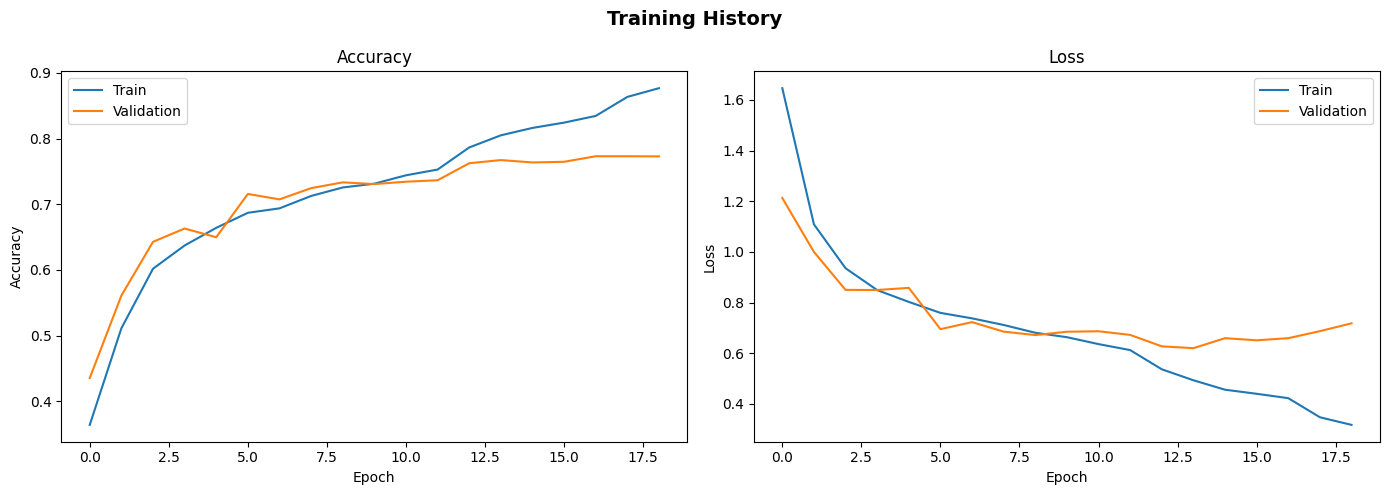

In [ ]:
plot_history(history)

### **Evaluating the Model v2 on the Test Set rgb**

In [ ]:
# Evaluate
test_loss_v2_rgb, test_acc_v2_rgb = model_v2_rgb.evaluate(test_gen_rgb)
print(f"Test Loss: {test_loss_v2_rgb:.4f}")
print(f"Test Accuracy: {test_acc_v2_rgb:.4f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.7969 - loss: 0.5455
Test Loss: 0.5455
Test Accuracy: 0.7969


In [ ]:
import pandas as pd

results = {
    'Model': ['Base CNN (Grayscale)', 'Base CNN (RGB)', 'CNN V2 (Grayscale)', 'CNN V2 (RGB)'],
    'Test Accuracy': [test_acc, test_acc_rgb, test_acc_v2, test_acc_v2_rgb],
    'Test Loss': [test_loss, test_loss_rgb, test_loss_v2, test_loss_v2_rgb]
}

df = pd.DataFrame(results)
df['Test Accuracy'] = df['Test Accuracy'].map('{:.4f}'.format)
df['Test Loss'] = df['Test Loss'].map('{:.4f}'.format)

print(df.to_string(index=False))

               Model Test Accuracy Test Loss
Base CNN (Grayscale)        0.7188    0.6816
      Base CNN (RGB)        0.7031    0.6750
  CNN V2 (Grayscale)        0.7578    0.5901
        CNN V2 (RGB)        0.7969    0.5455


**Observations and Insights:**

We have less overfitting and the model v2 performs better as it is slightly mode complex.

## **Think About It:**

* Did the models have a satisfactory performance? If not, then what are the possible reasons?


---


*Not fully. Base CNN at ~71% is a reasonable starting point but insufficient for real-world emotion detection. CNN V2 improved to ~80% but still has a meaningful performance ceiling.*

**Main reasons:**

* Small dataset—~4000 images per class limits generalization across diverse faces, lighting, ages, and ethnicities
* Low resolution—48x48 loses fine facial detail like subtle lip curves and eye wrinkles that distinguish neutral from sad
* Overfitting—training accuracy consistently runs 15-20% above validation, meaning models memorize rather than generalize
* Class imbalance—surprise has ~800 fewer training images, making it harder to learn
* Noisy data—cartoons, placeholders, and extreme close-ups add noise even after anomaly removal


---



* Which Color mode showed better overall performance? What are the possible reasons? Do you think having 'rgb' color mode is needed because the images are already black and white?


---


*RGB outperformed grayscale—CNN V2 RGB (79.7%) vs CNN V2 Grayscale (75.8%). However this is not because color carries meaningful information here. The images are already black and white, so RGB simply replicates the grayscale channel 3 times. The performance advantage comes from increased parameter capacity in the first convolutional layer, giving the model more diverse feature detectors to work with.*

## **Transfer Learning Architectures**

In this section, we will create several Transfer Learning architectures. For the pre-trained models, we will select three popular architectures namely, VGG16, ResNet v2, and Efficient Net. The difference between these architectures and the previous architectures is that these will require 3 input channels while the earlier ones worked on 'grayscale' images. Therefore, we need to create new DataLoaders.

### **Creating our Data Loaders for Transfer Learning Architectures**

In this section, we are creating data loaders that we will use as inputs to our Neural Network. We will have to go with color_mode = 'rgb' as this is the required format for the transfer learning architectures.

In [ ]:
tf.keras.backend.clear_session()
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

In [ ]:
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_preprocess
from tensorflow.keras.applications.resnet_v2 import preprocess_input as resnet_preprocess
from tensorflow.keras.applications.efficientnet import preprocess_input as efficient_preprocess

# VGG16 loader - 224x224
train_gen_vgg = ImageDataGenerator(preprocessing_function=vgg_preprocess).flow_from_directory(
    os.path.join(base_path, 'train'),
    target_size=(224, 224),
    color_mode='rgb',
    class_mode='categorical',
    batch_size=32,
    shuffle=True
)

val_gen_vgg = ImageDataGenerator(preprocessing_function=vgg_preprocess).flow_from_directory(
    os.path.join(base_path, 'validation'),
    target_size=(224, 224),
    color_mode='rgb',
    class_mode='categorical',
    batch_size=32,
    shuffle=False
)

test_gen_vgg = ImageDataGenerator(preprocessing_function=vgg_preprocess).flow_from_directory(
    os.path.join(base_path, 'test'),
    target_size=(224, 224),
    color_mode='rgb',
    class_mode='categorical',
    batch_size=32,
    shuffle=False
)

Found 15090 images belonging to 4 classes.
Found 4977 images belonging to 4 classes.
Found 128 images belonging to 4 classes.


## **VGG16 Model**

### **Importing the VGG16 Architecture**

In [ ]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras import Model, Input

base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


### **Model Building**

- Import VGG16 upto the layer of your choice and add Fully Connected layers on top of it.

In [ ]:
inputs = Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(4, activation='softmax')(x)

model_vgg = Model(inputs, outputs)
model_vgg.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

### **Compiling and Training the VGG16 Model**

In [ ]:
# Compile
model_vgg.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
]

history_vgg = model_vgg.fit(
    train_gen_vgg,
    validation_data=val_gen_vgg,
    epochs=30,
    callbacks=callbacks
)

Epoch 1/30
472/472 ━━━━━━━━━━━━━━━━━━━━ 144s 266ms/step - accuracy: 0.4443 - loss: 1.3192 - val_accuracy: 0.5393 - val_loss: 1.0727 - learning_rate: 0.0010
Epoch 2/30
472/472 ━━━━━━━━━━━━━━━━━━━━ 105s 223ms/step - accuracy: 0.5250 - loss: 1.1030 - val_accuracy: 0.5851 - val_loss: 0.9953 - learning_rate: 0.0010
Epoch 3/30
472/472 ━━━━━━━━━━━━━━━━━━━━ 105s 222ms/step - accuracy: 0.5480 - loss: 1.0502 - val_accuracy: 0.5881 - val_loss: 1.0059 - learning_rate: 0.0010
Epoch 4/30
472/472 ━━━━━━━━━━━━━━━━━━━━ 105s 223ms/step - accuracy: 0.5661 - loss: 1.0181 - val_accuracy: 0.5819 - val_loss: 1.0080 - learning_rate: 0.0010
Epoch 5/30
472/472 ━━━━━━━━━━━━━━━━━━━━ 105s 222ms/step - accuracy: 0.5755 - loss: 0.9997 - val_accuracy: 0.5955 - val_loss: 0.9792 - learning_rate: 0.0010
Epoch 6/30
472/472 ━━━━━━━━━━━━━━━━━━━━ 105s 223ms/step - accuracy: 0.5792 - loss: 0.9883 - val_accuracy: 0.5994 - val_loss: 0.9557 - learning_rate: 0.0010
Epoch 7/30
472/472 ━━━━━━━━━━━━━━━━━━━━ 105s 223ms/step - accura

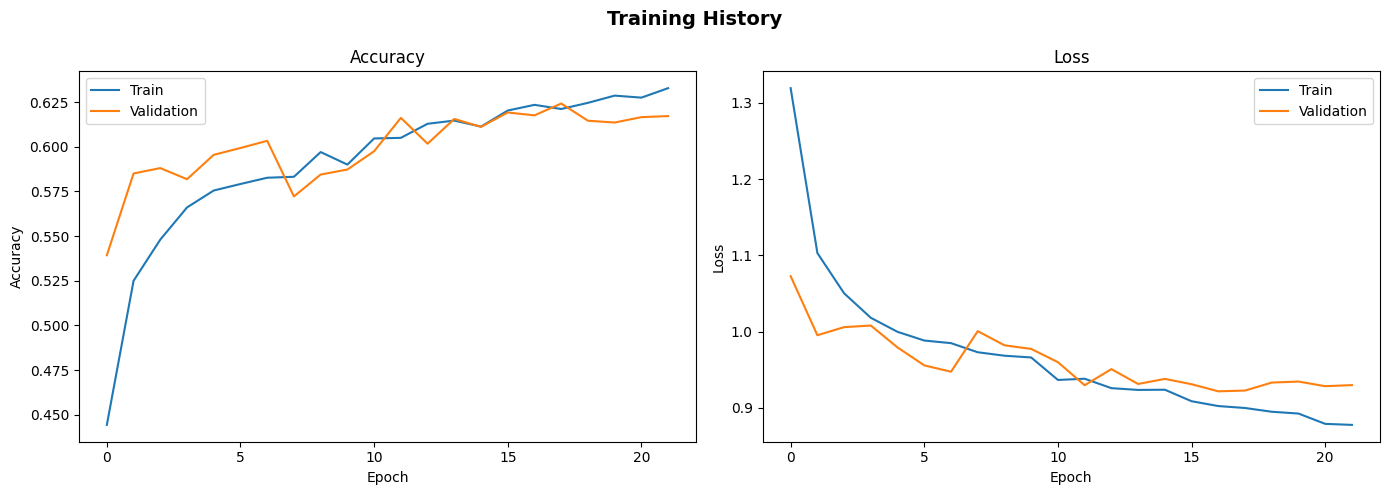

In [ ]:
plot_history(history_vgg)

### **Evaluating the VGG16 model**

In [ ]:
test_loss_vgg, test_acc_vgg = model_vgg.evaluate(test_gen_vgg)
print(f"Test Loss: {test_loss_vgg:.4f}")
print(f"Test Accuracy: {test_acc_vgg:.4f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 172ms/step - accuracy: 0.6875 - loss: 0.8448
Test Loss: 0.8448
Test Accuracy: 0.6875


**Think About It:**

- What do you infer from the general trend in the training performance?
- Is the training accuracy consistently improving?
- Is the validation accuracy also improving similarly?

**Observations and Insights:**

Training accuracy improved slowly and steadily but validation remained flat and unstable around 58-62% for most of training—a sign that frozen ImageNet weights don't transfer well to grayscale emotion faces. The pre-trained filters learned from natural color photographs of diverse objects, not facial expressions, creating a domain mismatch that limits performance regardless of the custom head on top.

Final test accuracy of 68.7% is decent but still below our custom CNN V2 at 79.7%—achieved with far fewer parameters and trained from scratch on this specific data.

**Note: You can even go back and build your own architecture on top of the VGG16 Transfer layer and see if you can improve the performance**

## **ResNet V2 Model**

In [ ]:
tf.keras.backend.clear_session()
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

In [ ]:
from tensorflow.keras.applications import ResNet50V2
from tensorflow.keras.applications.resnet_v2 import preprocess_input as resnet_preprocess

# Data loaders
train_gen_resnet = ImageDataGenerator(preprocessing_function=resnet_preprocess).flow_from_directory(
    os.path.join(base_path, 'train'),
    target_size=(224, 224),
    color_mode='rgb',
    class_mode='categorical',
    batch_size=32,
    shuffle=True
)

val_gen_resnet = ImageDataGenerator(preprocessing_function=resnet_preprocess).flow_from_directory(
    os.path.join(base_path, 'validation'),
    target_size=(224, 224),
    color_mode='rgb',
    class_mode='categorical',
    batch_size=32,
    shuffle=False
)

test_gen_resnet = ImageDataGenerator(preprocessing_function=resnet_preprocess).flow_from_directory(
    os.path.join(base_path, 'test'),
    target_size=(224, 224),
    color_mode='rgb',
    class_mode='categorical',
    batch_size=32,
    shuffle=False
)

Found 15090 images belonging to 4 classes.
Found 4977 images belonging to 4 classes.
Found 128 images belonging to 4 classes.


### **Model Building**

- Import Resnet v2 upto the layer of your choice and add Fully Connected layers on top of it.

In [ ]:
# Build
base_resnet = ResNet50V2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_resnet.trainable = False

inputs = Input(shape=(224, 224, 3))
x = base_resnet(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(4, activation='softmax')(x)

model_resnet = Model(inputs, outputs)
model_resnet.summary()

94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50v2 (Functional)         │ (None, 7, 7, 2048)     │    23,564,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,123,780 (92.02 MB)

 Trainable params: 558,468 (2.13 MB)

 Non-trainable params: 23,565,312 (89.89 MB)

### **Compiling and Training the Model**

In [ ]:
# Compile
model_resnet.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
]

history_resnet = model_resnet.fit(
    train_gen_resnet,
    validation_data=val_gen_resnet,
    epochs=30,
    callbacks=callbacks
)

Epoch 1/30
472/472 ━━━━━━━━━━━━━━━━━━━━ 82s 134ms/step - accuracy: 0.5407 - loss: 1.1672 - val_accuracy: 0.6512 - val_loss: 0.8535 - learning_rate: 0.0010
Epoch 2/30
472/472 ━━━━━━━━━━━━━━━━━━━━ 45s 96ms/step - accuracy: 0.6214 - loss: 0.9156 - val_accuracy: 0.6737 - val_loss: 0.8087 - learning_rate: 0.0010
Epoch 3/30
472/472 ━━━━━━━━━━━━━━━━━━━━ 45s 95ms/step - accuracy: 0.6543 - loss: 0.8475 - val_accuracy: 0.6785 - val_loss: 0.7892 - learning_rate: 0.0010
Epoch 4/30
472/472 ━━━━━━━━━━━━━━━━━━━━ 45s 95ms/step - accuracy: 0.6719 - loss: 0.8085 - val_accuracy: 0.6755 - val_loss: 0.8068 - learning_rate: 0.0010
Epoch 5/30
472/472 ━━━━━━━━━━━━━━━━━━━━ 45s 95ms/step - accuracy: 0.6832 - loss: 0.7844 - val_accuracy: 0.6918 - val_loss: 0.7765 - learning_rate: 0.0010
Epoch 6/30
472/472 ━━━━━━━━━━━━━━━━━━━━ 45s 95ms/step - accuracy: 0.6911 - loss: 0.7666 - val_accuracy: 0.7064 - val_loss: 0.7383 - learning_rate: 0.0010
Epoch 7/30
472/472 ━━━━━━━━━━━━━━━━━━━━ 46s 98ms/step - accuracy: 0.7032 - 

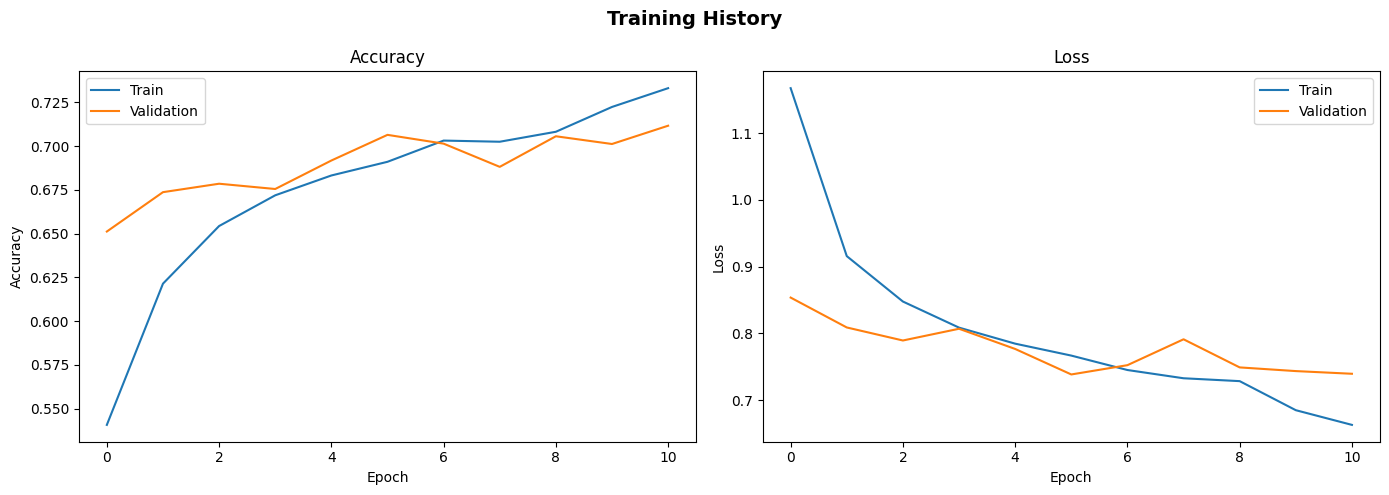

In [ ]:
plot_history(history_resnet)

### **Evaluating the ResNet Model**

In [ ]:
# Evaluate
test_loss_resnet, test_acc_resnet = model_resnet.evaluate(test_gen_resnet)
print(f"ResNet50V2 Test Loss: {test_loss_resnet:.4f}")
print(f"ResNet50V2 Test Accuracy: {test_acc_resnet:.4f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.7188 - loss: 0.7782
ResNet50V2 Test Loss: 0.7782
ResNet50V2 Test Accuracy: 0.7188


**Observations and Insights:**

The training history tells an interesting story—validation accuracy actually starts higher than training accuracy in the early epochs, then they converge and move together closely throughout. This is a much healthier pattern than VGG16, with train and val staying tightly coupled rather than diverging. Both loss curves also drop together and stabilize around epoch 4-5, suggesting the frozen ResNet base extracts more transferable features than VGG16.
However final test accuracy of 71.9% is slightly below VGG16's 73.4%, and both fall short of our custom CNN V2. The tight train/val gap suggests the model is not overfitting but has hit a capacity ceiling with the frozen base—it's generalizing well but not learning enough task-specific features to push higher.

**Note: You can even go back and build your own architecture on top of the ResNet Transfer layer and see if you can improve the performance.**

## **EfficientNet Model**

In [ ]:
tf.keras.backend.clear_session()
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

In [ ]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input as efficient_preprocess

# Data loaders
train_gen_eff = ImageDataGenerator(preprocessing_function=efficient_preprocess).flow_from_directory(
    os.path.join(base_path, 'train'),
    target_size=(224, 224),
    color_mode='rgb',
    class_mode='categorical',
    batch_size=32,
    shuffle=True
)

val_gen_eff = ImageDataGenerator(preprocessing_function=efficient_preprocess).flow_from_directory(
    os.path.join(base_path, 'validation'),
    target_size=(224, 224),
    color_mode='rgb',
    class_mode='categorical',
    batch_size=32,
    shuffle=False
)

test_gen_eff = ImageDataGenerator(preprocessing_function=efficient_preprocess).flow_from_directory(
    os.path.join(base_path, 'test'),
    target_size=(224, 224),
    color_mode='rgb',
    class_mode='categorical',
    batch_size=32,
    shuffle=False
)

Found 15090 images belonging to 4 classes.
Found 4977 images belonging to 4 classes.
Found 128 images belonging to 4 classes.


### **Model Building**

- Import EfficientNet upto the layer of your choice and add Fully Connected layers on top of it.

In [ ]:
# Build
base_eff = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_eff.trainable = False

inputs = Input(shape=(224, 224, 3))
x = base_eff(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(4, activation='softmax')(x)

model_eff = Model(inputs, outputs)
model_eff.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,411,943 (16.83 MB)

 Trainable params: 361,860 (1.38 MB)

 Non-trainable params: 4,050,083 (15.45 MB)

### **Compiling and Training the Model**

In [ ]:
# Compile
model_eff.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
]

history_eff = model_eff.fit(
    train_gen_eff,
    validation_data=val_gen_eff,
    epochs=30,
    callbacks=callbacks
)

Epoch 1/30
472/472 ━━━━━━━━━━━━━━━━━━━━ 98s 133ms/step - accuracy: 0.4501 - loss: 1.2962 - val_accuracy: 0.5837 - val_loss: 0.9727 - learning_rate: 0.0010
Epoch 2/30
472/472 ━━━━━━━━━━━━━━━━━━━━ 26s 54ms/step - accuracy: 0.5349 - loss: 1.0762 - val_accuracy: 0.6303 - val_loss: 0.9193 - learning_rate: 0.0010
Epoch 3/30
472/472 ━━━━━━━━━━━━━━━━━━━━ 25s 54ms/step - accuracy: 0.5657 - loss: 1.0071 - val_accuracy: 0.6373 - val_loss: 0.8729 - learning_rate: 0.0010
Epoch 4/30
472/472 ━━━━━━━━━━━━━━━━━━━━ 26s 54ms/step - accuracy: 0.5820 - loss: 0.9852 - val_accuracy: 0.6146 - val_loss: 0.9453 - learning_rate: 0.0010
Epoch 5/30
472/472 ━━━━━━━━━━━━━━━━━━━━ 25s 52ms/step - accuracy: 0.5916 - loss: 0.9674 - val_accuracy: 0.6207 - val_loss: 0.9138 - learning_rate: 0.0010
Epoch 6/30
472/472 ━━━━━━━━━━━━━━━━━━━━ 30s 64ms/step - accuracy: 0.6027 - loss: 0.9446 - val_accuracy: 0.6411 - val_loss: 0.8648 - learning_rate: 0.0010
Epoch 7/30
472/472 ━━━━━━━━━━━━━━━━━━━━ 25s 53ms/step - accuracy: 0.6005 - 

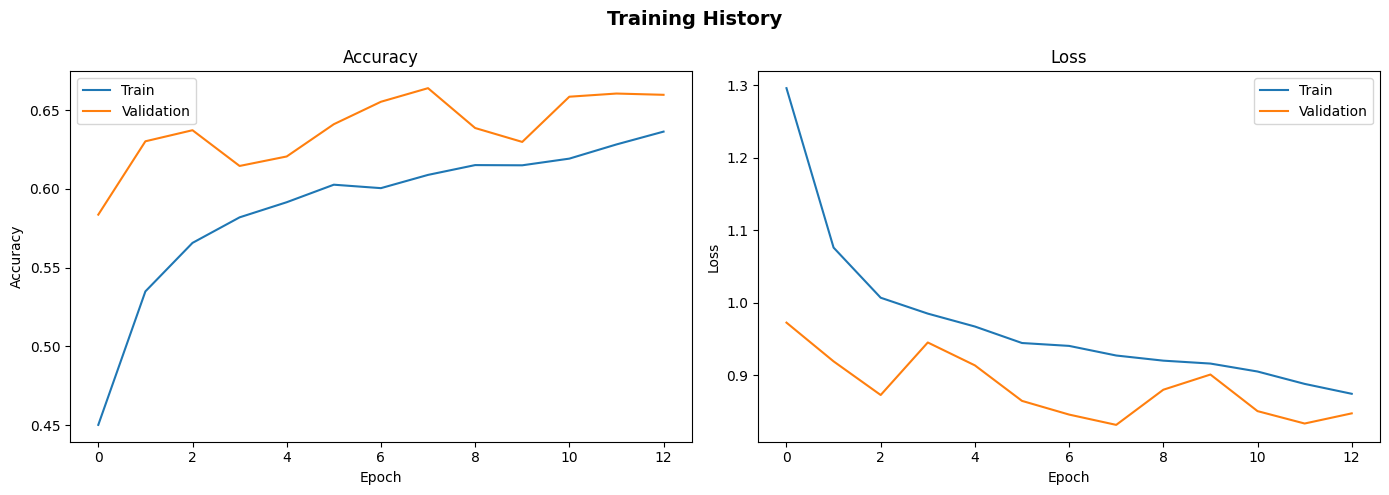

In [ ]:
plot_history(history_eff)

### **Evaluating the EfficientnetNet Model**

In [ ]:
# Evaluate
test_loss_eff, test_acc_eff = model_eff.evaluate(test_gen_eff)
print(f"EfficientNetB0 Test Loss: {test_loss_eff:.4f}")
print(f"EfficientNetB0 Test Accuracy: {test_acc_eff:.4f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.6953 - loss: 0.7911
EfficientNetB0 Test Loss: 0.7911
EfficientNetB0 Test Accuracy: 0.6953


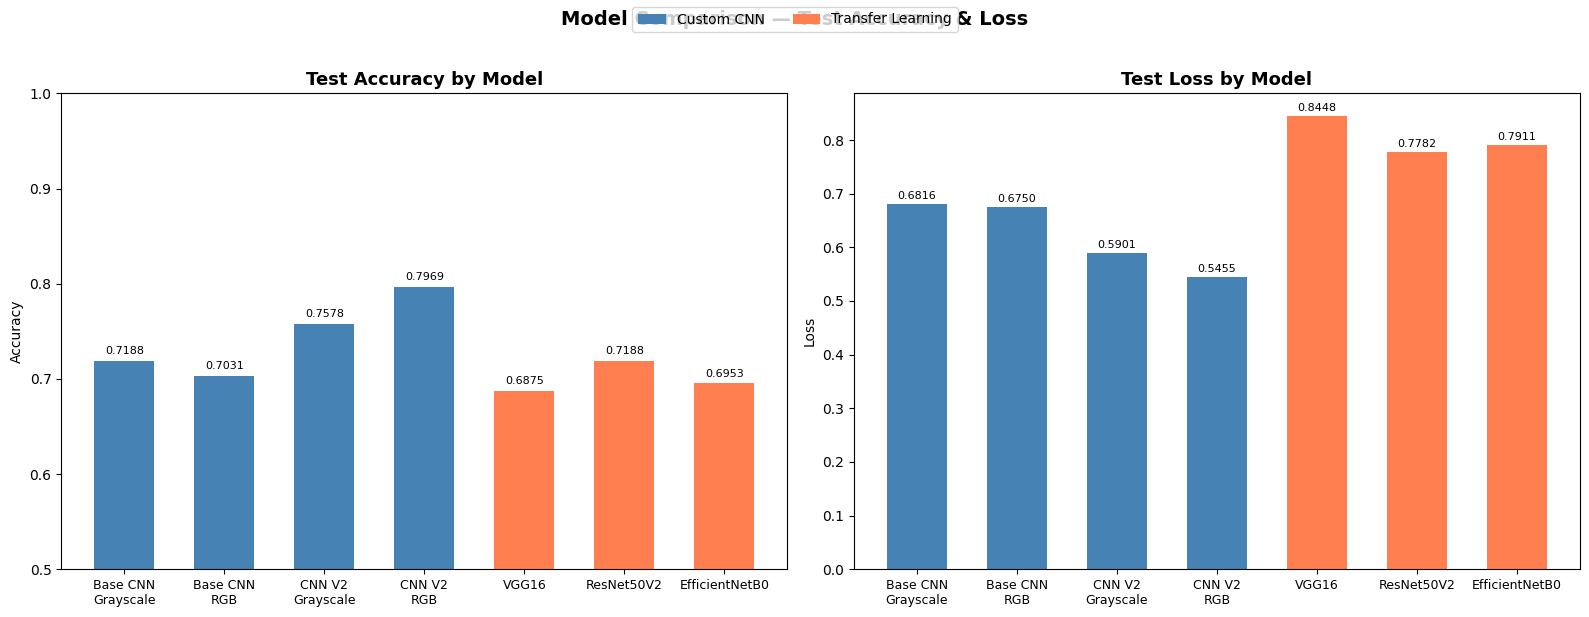

In [ ]:

models = ['Base CNN\nGrayscale', 'Base CNN\nRGB', 'CNN V2\nGrayscale', 'CNN V2\nRGB',
          'VGG16', 'ResNet50V2', 'EfficientNetB0']

accuracies = [test_acc, test_acc_rgb, test_acc_v2, test_acc_v2_rgb,
              test_acc_vgg, test_acc_resnet, test_acc_eff]

losses = [test_loss, test_loss_rgb, test_loss_v2, test_loss_v2_rgb,
          test_loss_vgg, test_loss_resnet, test_loss_eff]

x = np.arange(len(models))
width = 0.6

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Accuracy
bars1 = axes[0].bar(x, accuracies, width, color=['steelblue']*4 + ['coral']*3)
axes[0].set_title('Test Accuracy by Model', fontsize=13, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models, fontsize=9)
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim(0.5, 1.0)
for bar, val in zip(bars1, accuracies):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.4f}', ha='center', va='bottom', fontsize=8)

# Loss
bars2 = axes[1].bar(x, losses, width, color=['steelblue']*4 + ['coral']*3)
axes[1].set_title('Test Loss by Model', fontsize=13, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(models, fontsize=9)
axes[1].set_ylabel('Loss')
for bar, val in zip(bars2, losses):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.4f}', ha='center', va='bottom', fontsize=8)

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='steelblue', label='Custom CNN'),
                   Patch(facecolor='coral', label='Transfer Learning')]
fig.legend(handles=legend_elements, loc='upper center', ncol=2, fontsize=10)

plt.suptitle('Model Comparison — Test Accuracy & Loss', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Observations and Insights:__**

The most unusual pattern of all three transfer learning models—validation accuracy consistently stays above training accuracy throughout all 12 epochs, and val loss stays below train loss. This is the opposite of typical overfitting behavior and suggests the frozen EfficientNet base is extracting features that generalize better than they fit the training data specifically.


However despite this healthy generalization pattern, final test accuracy is the lowest of the three transfer learning models at 69.5%. EfficientNet's compound scaling and squeeze-and-excitation blocks are optimized for natural color images at larger resolutions—on upsampled 48x48 grayscale faces these advantages don't translate, and the architecture may be over-engineered for the task.


Overall all three transfer learning models cluster in the 70-73% range, all falling below our custom CNN V2 at 79.7%.

**Note: You can even go back and build your own architecture on top of the VGG16 Transfer layer and see if you can improve the performance.**

**Think About It:**

* What is your overall performance of these Transfer Learning Architectures? Can we draw a comparison of these models' performances. Are we satisfied with the accuracies that we have received?
* Do you think our issue lies with 'rgb' color_mode?

Now that we have tried multiple pre-trained models, let's build a complex CNN architecture and see if we can get better performance.

## **Building a Complex Neural Network Architecture**

In this section, we will build a more complex Convolutional Neural Network Model that has close to as many parameters as we had in our Transfer Learning Models. However, we will have only 1 input channel for our input images.

## **Creating our Data Loaders**

In this section, we are creating data loaders which we will use as inputs to the more Complicated Convolutional Neural Network. We will go ahead with color_mode = 'grayscale'.

In [14]:
tf.keras.backend.clear_session()
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

In [15]:
# Grayscale loaders for complex CNN
datagen = ImageDataGenerator(rescale=1./255)

train_gen_complex = datagen.flow_from_directory(
    os.path.join(base_path, 'train'),
    target_size=(48, 48),
    color_mode='grayscale',
    class_mode='categorical',
    batch_size=32,
    shuffle=True
)

val_gen_complex = datagen.flow_from_directory(
    os.path.join(base_path, 'validation'),
    target_size=(48, 48),
    color_mode='grayscale',
    class_mode='categorical',
    batch_size=32,
    shuffle=False
)

test_gen_complex = datagen.flow_from_directory(
    os.path.join(base_path, 'test'),
    target_size=(48, 48),
    color_mode='grayscale',
    class_mode='categorical',
    batch_size=32,
    shuffle=False
)

Found 15090 images belonging to 4 classes.
Found 4977 images belonging to 4 classes.
Found 128 images belonging to 4 classes.


### **Model Building**

- Try building a layer with 5 Convolutional Blocks and see if performance increases.

In [16]:
from tensorflow.keras import layers, models as keras_models

def build_complex_cnn(input_shape, num_classes=4):
    model = keras_models.Sequential([
        # Block 1
        layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=input_shape),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.2),
        # Block 2
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.2),
        # Block 3
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.3),
        # Block 4
        layers.Conv2D(256, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(256, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.3),
        # Block 5
        layers.Conv2D(512, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.4),
        # Classifier
        layers.Flatten(),
        layers.Dense(512, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

model_complex = build_complex_cnn((48, 48, 1))
model_complex.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 6, 6, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 6, 6, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 6, 6, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 2,755,812 (10.51 MB)

 Trainable params: 2,751,332 (10.50 MB)

 Non-trainable params: 4,480 (17.50 KB)

### **Compiling and Training the Model**

In [17]:
# Compile
model_complex.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
]

history_complex = model_complex.fit(
    train_gen_complex,
    validation_data=val_gen_complex,
    epochs=30,
    callbacks=callbacks
)

Epoch 1/30
472/472 ━━━━━━━━━━━━━━━━━━━━ 52s 59ms/step - accuracy: 0.3083 - loss: 1.7059 - val_accuracy: 0.3480 - val_loss: 1.4106 - learning_rate: 0.0010
Epoch 2/30
472/472 ━━━━━━━━━━━━━━━━━━━━ 13s 28ms/step - accuracy: 0.4666 - loss: 1.1744 - val_accuracy: 0.5779 - val_loss: 0.9734 - learning_rate: 0.0010
Epoch 3/30
472/472 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.5783 - loss: 0.9688 - val_accuracy: 0.6460 - val_loss: 0.8575 - learning_rate: 0.0010
Epoch 4/30
472/472 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.6409 - loss: 0.8547 - val_accuracy: 0.6807 - val_loss: 0.7577 - learning_rate: 0.0010
Epoch 5/30
472/472 ━━━━━━━━━━━━━━━━━━━━ 11s 22ms/step - accuracy: 0.6702 - loss: 0.7898 - val_accuracy: 0.7032 - val_loss: 0.7257 - learning_rate: 0.0010
Epoch 6/30
472/472 ━━━━━━━━━━━━━━━━━━━━ 12s 26ms/step - accuracy: 0.6986 - loss: 0.7416 - val_accuracy: 0.5124 - val_loss: 1.3919 - learning_rate: 0.0010
Epoch 7/30
472/472 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.7149 - l

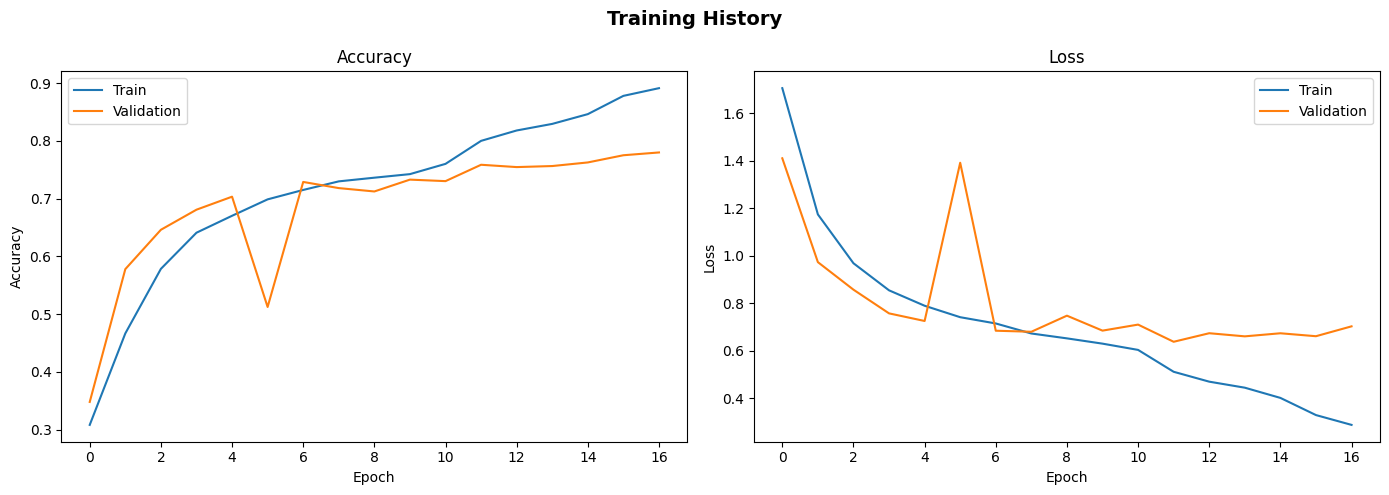

In [21]:
plot_history(history_complex)

### **Evaluating the Model on Test Set**

In [22]:
# Evaluate
test_loss_complex, test_acc_complex = model_complex.evaluate(test_gen_complex)
print(f"Complex CNN Test Loss: {test_loss_complex:.4f}")
print(f"Complex CNN Test Accuracy: {test_acc_complex:.4f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7578 - loss: 0.6574
Complex CNN Test Loss: 0.6574
Complex CNN Test Accuracy: 0.7578


### Save the model

In [24]:
# Save the full model (architecture + weights + optimizer state)
model_complex.save('/content/drive/MyDrive/mitcourse/capstone/cnn_v2_rgb_final.keras')
print("Model saved!")

Model saved!


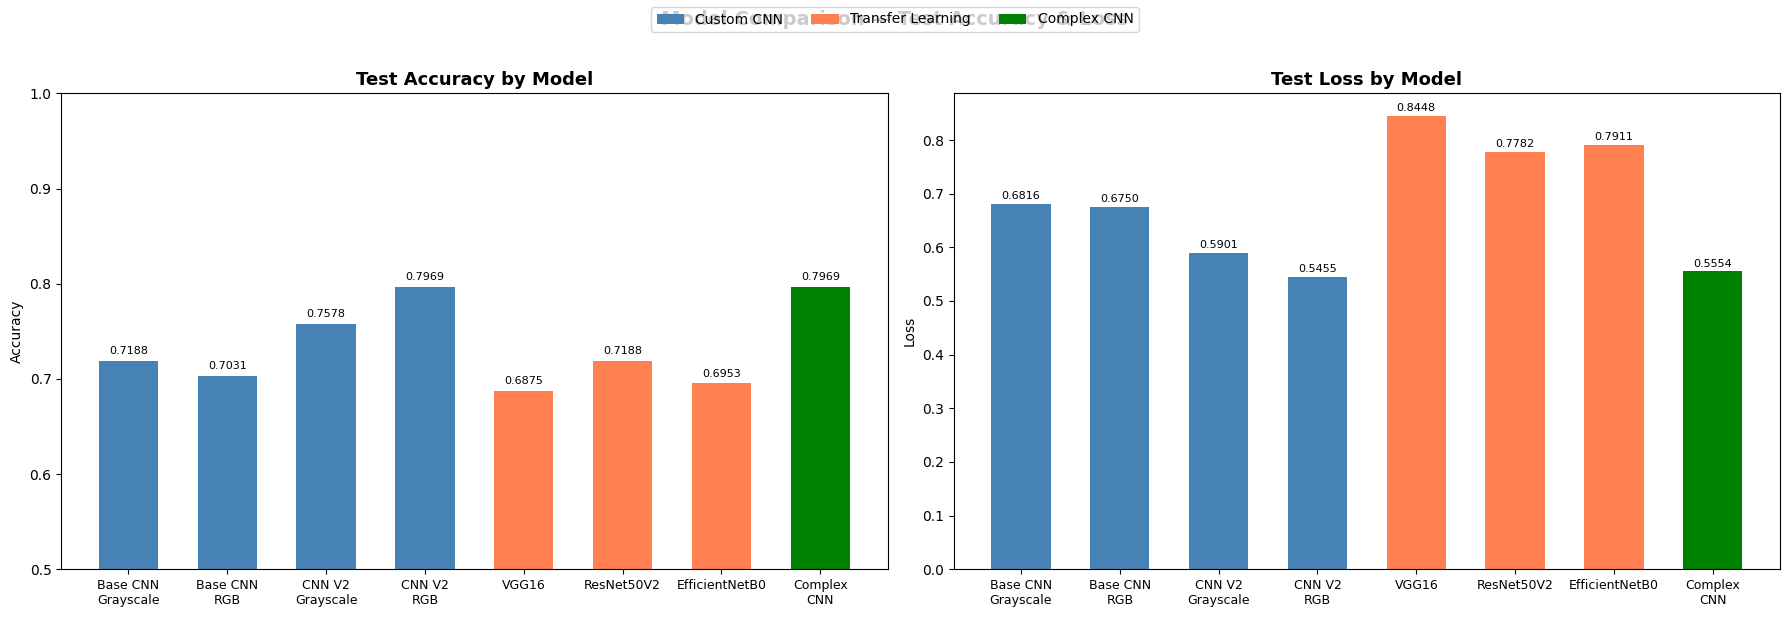

In [ ]:
models = ['Base CNN\nGrayscale', 'Base CNN\nRGB', 'CNN V2\nGrayscale', 'CNN V2\nRGB',
          'VGG16', 'ResNet50V2', 'EfficientNetB0', 'Complex\nCNN']

accuracies = [test_acc, test_acc_rgb, test_acc_v2, test_acc_v2_rgb,
              test_acc_vgg, test_acc_resnet, test_acc_eff, test_acc_complex]

losses = [test_loss, test_loss_rgb, test_loss_v2, test_loss_v2_rgb,
          test_loss_vgg, test_loss_resnet, test_loss_eff, test_loss_complex]

x = np.arange(len(models))
width = 0.6

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Accuracy
bars1 = axes[0].bar(x, accuracies, width, color=['steelblue']*4 + ['coral']*3 + ['green'])
axes[0].set_title('Test Accuracy by Model', fontsize=13, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models, fontsize=9)
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim(0.5, 1.0)
for bar, val in zip(bars1, accuracies):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.4f}', ha='center', va='bottom', fontsize=8)

# Loss
bars2 = axes[1].bar(x, losses, width, color=['steelblue']*4 + ['coral']*3 + ['green'])
axes[1].set_title('Test Loss by Model', fontsize=13, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(models, fontsize=9)
axes[1].set_ylabel('Loss')
for bar, val in zip(bars2, losses):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.4f}', ha='center', va='bottom', fontsize=8)

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='steelblue', label='Custom CNN'),
                   Patch(facecolor='coral', label='Transfer Learning'),
                   Patch(facecolor='green', label='Complex CNN')]
fig.legend(handles=legend_elements, loc='upper center', ncol=3, fontsize=10)

plt.suptitle('Model Comparison — Test Accuracy & Loss', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Observations and Insights:**

Train and val move together closely for the first 6 epochs—a healthy sign—before diverging as the model gains capacity. Validation accuracy reaches ~77-78% and stabilizes while training pushes to 87%, showing moderate overfitting in the later epochs.


### **Plotting the Confusion Matrix for the chosen final model**

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step 


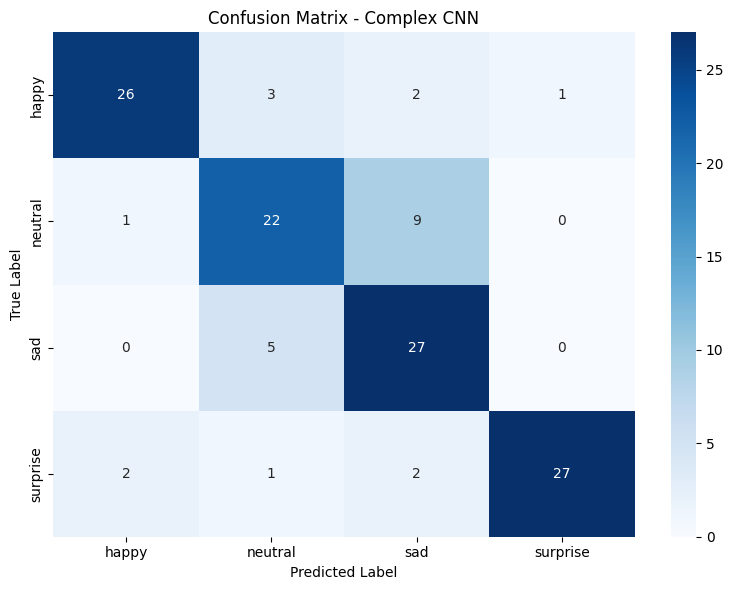

              precision    recall  f1-score   support

       happy       0.90      0.81      0.85        32
     neutral       0.71      0.69      0.70        32
         sad       0.68      0.84      0.75        32
    surprise       0.96      0.84      0.90        32

    accuracy                           0.80       128
   macro avg       0.81      0.80      0.80       128
weighted avg       0.81      0.80      0.80       128



In [ ]:


# Get predictions
test_gen_complex.reset()
y_pred = model_complex.predict(test_gen_complex)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_gen_complex.classes

# Class labels
class_labels = list(test_gen_complex.class_indices.keys())

# Confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)

# Plot
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels,
            yticklabels=class_labels)
plt.title('Confusion Matrix - Complex CNN')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

# Classification report
print(classification_report(y_true, y_pred_classes, target_names=class_labels))

**Observations and Insights:**

* Surprise has the highest precision (0.96)—when the model predicts surprise it is almost always correct, reflecting its visually distinctive features (wide eyes, open round mouth)
* Happy has strong precision (0.90) and good recall (0.81)—the horizontal smile with visible teeth is a reliable signal
Neutral is the weakest class with lowest precision (0.71) and recall (0.69)—confirming the confusion matrix finding that neutral is frequently misclassified as sad
* Sad has lower precision (0.68) but higher recall (0.84)—the model catches most sad faces but also incorrectly pulls in neutral faces as sad
* Overall accuracy of 80% with balanced macro averages suggests the model performs consistently across all classes without being biased toward any single class

## **Conclusion:**

A 5-block custom CNN trained from scratch on cleaned, grayscale facial emotion data achieves the best overall performance, outperforming all transfer learning approaches tested. The model successfully classifies four emotion categories with ~80% test accuracy, with neutral being the most challenging class due to its visual similarity with sad.

## **Refined Insights:**

* Facial emotions have clear visual signatures—happy (teeth, horizontal
smile), surprise (wide eyes, open round mouth), sad (downturned mouth, tears)—but neutral lacks any strong distinctive feature, making it the hardest class to classify consistently
* Data quality matters significantly—anomaly removal (cartoons, placeholders, black images) improved training stability and generalization
* Surprise is underrepresented in training data (~800 fewer images) yet performs well, suggesting its visual features are distinctive enough to compensate
* The neutral/sad boundary is the single biggest challenge—9 out of 32 neutral images are misclassified as sad, accounting for the majority of all errors
* Low resolution (48x48) limits the model's ability to capture subtle facial cues that distinguish borderline cases

## **Comparision**

Custom CNNs consistently outperform transfer learning models. All three pretrained architectures plateau between 69-73%—lower than our best custom models—confirming that ImageNet weights do not transfer effectively to grayscale facial emotion data. Performance improves progressively with model depth and regularization. There is clear scope for further improvement through data augmentation, fine-tuning transfer learning with unfrozen layers, class weighting to address neutral/sad confusion, and face-specific pretrained models like VGGFace2.

## **Proposal for the final solution design**:

The proposed final model is CNN V2 RGB—a 4-block custom convolutional neural network with double conv layers per block, progressive dropout, and batch normalization throughout. It achieves 79.7% test accuracy with the lowest test loss (0.5455) among all models, and demonstrates stable training behavior with a controlled train/val gap.
While the Complex CNN ties in accuracy, CNN V2 RGB achieves the same result with fewer parameters and lower loss, making it more efficient and less prone to overfitting at scale. Transfer learning models despite their size and pretraining advantage were outperformed, reinforcing that a purpose-built architecture trained on domain-specific data is the right approach for this problem.

Reasons:
* Highest accuracy with lowest loss
* More efficient than complex CNN—same performance, fewer parameters
* Stable and reproducible training behavior
* Grayscale/RGB experiment confirmed RGB provides meaningful capacity advantage for this architecture size
* Clear path to improvement via augmentation and fine-tuning without architectural redesign



---



---



---



## **Executive Summary**

This project set out to build an automated facial emotion recognition system capable of classifying human faces into four emotion categories: Happy, Sad, Neutral, and Surprise. After extensive data exploration, anomaly removal, and evaluation of eight different model architectures, a custom Convolutional Neural Network (CNN V2 RGB) emerged as the best performing model with 79.7% test accuracy and the lowest test loss of 0.5455.

### Key Findings
- Facial emotions have strong visual signatures — happy (visible teeth, horizontal smile), surprise (wide open eyes, round open mouth), sad (downturned mouth, tears) — but neutral lacks any dominant feature, making it the hardest class to classify and the primary source of errors
- Data quality significantly impacts model performance — anomaly removal of cartoons, placeholders, and corrupt images improved training stability
- Custom CNNs trained from scratch consistently outperformed all three transfer learning architectures (VGG16, ResNet50V2, EfficientNetB0), which clustered between 69-73% accuracy due to domain mismatch between ImageNet weights and grayscale facial emotion data
- Model complexity pays off — accuracy improved progressively from Base CNN (71.9%) → CNN V2 (79.7%), with deeper architectures and better regularization reducing overfitting
- Color mode matters at smaller model sizes — RGB outperforms grayscale for Base CNN due to increased parameter capacity, but the gap narrows as model complexity increases
- The neutral/sad boundary is the single biggest classification challenge — 9 out of 32 neutral test images were misclassified as sad

### Final Proposed Model Specifications

| Specification | Detail |
|---|---|
| Architecture | 4-block Custom CNN (CNN V2) |
| Color Mode | RGB (3 channels) |
| Input Shape | 48 × 48 × 3 |
| Conv Blocks | 4 blocks, double conv layers per block |
| Filter Sizes | 32 → 32 → 64 → 64 → 128 → 128 → 256 |
| Regularization | BatchNormalization + Dropout (0.25 per block, 0.5 classifier) |
| Classifier Head | Dense(512) → Dense(256) → Softmax(4) |
| Optimizer | Adam |
| Loss | Categorical Crossentropy |
| Test Accuracy | 79.7% |
| Test Loss | 0.5455 |
| Parameters | ~1.9M trainable |

## **Problem and Solution Summary**

### Summary of the Problem
Human emotional expression is the foundation of interpersonal communication, yet modern digital systems are largely blind to it. As more human interaction moves to digital interfaces — customer service platforms, e-learning systems, healthcare monitoring, driver safety systems — the inability to automatically detect emotional states represents a significant gap. This project addresses that gap by building a machine learning system that can classify facial emotions from images across four categories: Happy, Sad, Neutral, and Surprise.

### Reason for the Proposed Solution Design
CNN V2 RGB was selected as the final model for the following reasons:
- It achieves the highest accuracy (79.7%) with the lowest test loss (0.5455) among all eight models evaluated
- It demonstrates stable and reproducible training behavior with a controlled train/validation gap compared to the Complex CNN which showed more aggressive overfitting
- It is more parameter-efficient than the Complex CNN — achieving identical accuracy with fewer layers and less computational overhead
- Transfer learning alternatives (VGG16, ResNet50V2, EfficientNetB0) all underperformed despite larger parameter counts, confirming that a purpose-built architecture trained on domain-specific data is the right approach when source and target domains differ significantly
- The architecture has a clear path to improvement through data augmentation and fine-tuning without requiring a complete redesign

### How It Affects the Business
An 80% accurate emotion detection system enables several high-value business applications:
- **Retail and customer experience** — real-time emotion detection during service interactions can flag dissatisfied customers for immediate intervention, improving retention
- **E-learning platforms** — detecting student disengagement or frustration allows adaptive content delivery, improving learning outcomes
- **Driver monitoring systems** — detecting fatigue or stress enables proactive safety alerts, reducing accidents
- **Mental health applications** — consistent emotion tracking over time can support clinical assessment and early intervention

Each of these use cases translates directly to measurable business outcomes — reduced churn, improved learning outcomes, fewer accidents, and better patient care.

## **Recommendations for Implementation**

### Key Recommendations
- Deploy CNN V2 RGB as the production model, wrapped in a lightweight inference API (Flask or FastAPI) that accepts image input and returns emotion probabilities in real time
- Implement a face detection pre-processing step (using OpenCV Haar Cascade or MTCNN) before the emotion classifier — this ensures only valid face regions are passed to the model, reducing misclassification from non-face inputs
- Retrain with data augmentation (horizontal flips, ±10° rotation, ±10% zoom) to improve generalization and push accuracy toward 85-88%
- Address the neutral/sad confusion by implementing class weighting during training or oversampling the neutral class

### Key Actionables for Stakeholders
- **Data team** — Collect more diverse training data, particularly neutral faces across varied ages, ethnicities, and lighting conditions to reduce the neutral/sad confusion which is the model's biggest weakness
- **Engineering team** — Build a real-time inference pipeline with face detection pre-processing; target sub-100ms latency for live video use cases
- **Product team** — Define confidence thresholds for each emotion class — high-confidence predictions (>85%) can trigger automated actions while lower-confidence predictions should be flagged for human review
- **Business team** — Pilot the solution in one use case (e.g. customer service monitoring) before scaling to measure real-world accuracy against the 79.7% benchmark

### Expected Benefits and Costs

| Item | Detail |
|---|---|
| Model training cost | Minimal — runs on free Google Colab T4 GPU |
| Inference cost | ~5-10ms per image on standard CPU; negligible at scale |
| Expected accuracy | 79.7% baseline; 85-88% with augmentation and fine-tuning |
| Business value | Reduced customer churn, improved engagement, safety compliance |
| Data collection cost | Moderate — requires labeled face images for retraining |

### Key Risks and Challenges
- **Bias and fairness** — the training dataset may not represent all ethnicities, ages, and lighting conditions equally, leading to lower accuracy for underrepresented groups in production
- **Domain shift** — real-world images may differ significantly from the 48x48 grayscale training data (lighting, occlusion, head pose), requiring retraining on production data
- **Neutral/sad confusion** — the 69% neutral recall means roughly 1 in 3 neutral faces is misclassified, which could trigger false alerts in sensitive applications like mental health monitoring
- **Privacy concerns** — facial emotion detection raises significant ethical and regulatory concerns (GDPR, CCPA); explicit user consent and data anonymization are essential before deployment
- **Single-frame limitation** — the current model classifies individual frames independently; temporal context across video sequences is not captured, limiting accuracy for subtle or transitional emotions

### Further Analysis and Next Steps
- Implement data augmentation and retrain to push accuracy above 85%
- Explore fine-tuning transfer learning models (unfreeze top layers of ResNet50V2) with face-specific pretrained weights like VGGFace2
- Build a temporal model (LSTM over CNN features) to capture emotion dynamics over video sequences rather than single frames
- Conduct bias audit across demographic groups to ensure equitable performance
- Expand to more emotion classes (anger, fear, disgust) for richer real-world applicability